# Feature analysis — `volume_normalised`

This notebook follows the project's standard feature-analysis **method** (see
`notebooks/features/template.ipynb` and its worked example `price_dislocation`, and the sibling
activity features `volume_surge` and `mid_rate_surge`) and applies it to one new feature:
**`volume_normalised`** — a single EMA of a venue's traded volume, **regime-normalised**. The text
explains what to do and why; the code does it.

We build features for a model that forecasts one exchange's mid-price about 100 ms ahead. Three
crypto exchanges appear throughout — **byb** (Bybit), **bin** (Binance), **okx** (OKX) — and
**byb is the target**: the one we predict. ("Mid-price" = the midpoint between the best buy and
best sell quote.) The next section recaps the two-head model these features feed.

**The feature, in one line.**

`volume_normalised(ex; span)  =  ema_span(volume_ex)  /  yardstick`

where `ema_span(volume_ex)` is a **single** span-`N` EMA of venue `ex`'s per-trade-event traded
size (the **exp-weighted mean traded qty per trade-event**, an `E/W` `KernelMeanEMA`), and the
`yardstick` is **one of three** choices we build and compare: **none** (the un-normalised
baseline), **`σ_ev`** (the volatility yardstick), or **`λ_ev`** (the rate yardstick). A high value
means byb-comparable trades have been **large** lately, relative to the chosen regime gauge.

**A feature is "done" when two checks pass:**
- **The oracle (§4)** — the optimized build really computes what we think it does, **bit-exact**
  against a dead-simple independent streaming reference on a real data block, **for every
  per-exchange leg and every normalisation**.
- **The hygiene gates (§5/§6)** — the signal is real and holds in any market, not just an echo of
  "the market is volatile / busy right now."

> **Relationship to `volume_surge` (read this).** `volume_surge` and `volume_normalised` share the
> **same raw atom** — an EMA of traded volume — but explore **orthogonal axes**. `volume_surge` is
> `ema_fast(vol) / ema_slow(vol)`: a *self-normalising* ratio of two spans (the **fast/slow** axis),
> dimensionless by construction. `volume_normalised` is `ema_span(vol) / yardstick`: a *single*
> span divided by an *external* regime gauge (the **normalisation** axis). The fast/slow ratio
> cancels the volume *units* internally; dividing by a yardstick instead keeps one span's level but
> rescales it into vol- or rate-units. We expect them to carry *related* intensity information; §6
> reports `volume_normalised`'s marginal **over the controls**, and the natural follow-up is its
> marginal over `volume_surge` itself (noted in §10).

## The model these features feed: two heads

We forecast how byb's mid-price moves over the next ~100 ms, split into two simpler questions —
the two **heads**:

**Price head — which way and how far?** Over the next few price-moves, what is the *signed* move
(direction *and* size)? Its target is `price change ÷ σ_ev`, where `σ_ev` is byb's **volatility
yardstick** (the exp-weighted RMS of byb's *actual* mid-moves).

**Rate head — how many moves?** Busy markets pack many price-moves into the window, quiet ones few.
This head predicts the *count* of moves over the next 100 ms, against the recent pace — the **rate
yardstick** `λ_ev` — so its target is `count ÷ λ_ev`.

**What's a yardstick?** A causal, trailing estimate of byb's *volatility* (`σ_ev`) and move *rate*
(`λ_ev`), from past data only. Both are EMAs **decayed on the trade clock** (`α = 2/(span+1)`) but
**updated between trades** — they react to every byb mid-move, so they read live at every instant.
They use one fixed span, `YARDSTICK_N`. **Here they play a double role:** they build the §5 controls
and the rate-head target (as always), *and* they are the **normalisers** the feature is divided by —
so the normalisation axis is "which model yardstick, if any, makes the raw volume EMA most useful."

**Why split into two heads?** A move over a window is *how many* little moves times *how big* each
one is. Pulling "how many" (rate) apart from "how big" (price) lets each head learn a steadier
thing — the classic **subordination** decomposition (Clark 1973; Ané & Geman 2000): returns over
fixed clock-time look messy, but become well-behaved once you condition on the *number* of events.
Trade **volume** is the canonical subordinator/clock for price moves, so a volume EMA is squarely a
**how-many** (intensity) feature.

`volume_normalised` is **primarily a rate-head (intensity)** feature — heavier recent trading should
precede more byb mid-moves — but we check both heads, because the model is fed the **signed** feature
for *both* and lets each head learn what it can.

## Guard rails — do this, not that

Hard rules, learned the hard way. Follow them unless you have a specific, written reason not to.

**Don't**
- **Don't assume a fixed leader.** No exchange always leads. Build the feature the same way for
  **every** venue (byb, okx, bin) and keep them all — byb is the target's own volume; the okx/bin
  legs test whether another venue's trade size leads byb's move-rate.
- **Don't pick "the best exchange"** by average score — keep all; let the model weight them. Check
  per-exchange vs single vs pooled across time-scales (§9).
- **Don't normalize reflexively — but DO test it here, because that is the whole point of this
  feature.** A raw volume EMA is **not** dimensionless (unlike `volume_surge`'s ratio): its level
  carries the venue's intrinsic trade size *and* the volatility/rate regime. So the normalisation
  axis is a genuine question — we build the **un-normalised baseline**, `/ σ_ev`, and `/ λ_ev`, and
  **report which (if any) actually helps**, rather than assuming.
- **Don't invent your own vol/rate scale.** When we do normalize, we use the **model's** yardsticks
  (`σ_ev`, `λ_ev`) so the feature shares units with the target.
- **Don't trust a correlation** until it survives the rate/vol regime controls — *especially acute
  here* (see the circularity caveat in §5: a volume EMA co-moves with the rate regime).
- **Don't ship a feature without the oracle** (§4) matching a dead-simple independent version — for
  **every** per-exchange leg.
- **Don't peek ahead.** Every value uses only data at-or-before its own timestamp.
- **Don't over-transform for the network.** Pick the lightest reshaping that works (§8).

**Do**
- **Do start with a falsifiable hypothesis** — a recent surge in *traded size* precedes more byb
  mid-moves. Disproof: no link to the forward move-count at any span/normalisation for any venue;
  or the link fully explained by the rate/vol controls.
- **Do make every average a trade-tick EMA.** *Every* smoother — the volume EMA, `σ_ev`, `λ_ev` — is
  an exponential moving average **decayed once per trade-timestamp** (`α = 2/(span+1)`), O(1) state,
  bit-identical online vs offline.
- **Do read a sparse flow as `E / W`.** A venue's `qty` is carried only on *its* trade events. The
  volume EMA is a **`KernelMeanEMA`**: `add(Σqty)` on a venue trade (weight 1), `tick()` on every
  shared trade-timestamp; read `E / W` = mean qty **per venue trade**, with the non-venue ticks
  cancelling instead of counting as zeros and the warm-up bias divided out. (Pushing a `0` on a
  non-venue trade would silently turn "mean qty per venue trade" into "mean qty per *any* trade".)
- **Do treat all records sharing a timestamp as ONE event.** A burst of a venue's prints at the
  exact same instant (one order sweeping levels) is **one event carrying many fills** — **sum** their
  `qty` into a single injection; the shared clock advances **once** for that timestamp.
- **Do test against both heads — but feed both the *signed* feature.** The magnitude→intensity
  (rate-head) check is the one that matters; the price-head check is a diagnostic we expect weak.
- **Do score out-of-sample** with a purged, embargoed walk-forward (strictly past→future).
- **Do treat a feature as a family** — here across **single-EMA spans** *and* across **normalisations**
  — and let the data pick (§6).

## Choosing the EMA — the part that's easy to get silently wrong

Every smoother here is an EMA on the **trade clock**: its **decay** steps once per *trade-timestamp*
(`α = 2/(span+1)`), but its **value updates on every relevant event in between**, so a read is never
stale. For `volume_normalised` the moving parts are:

**Choice 1 — which EMA, and how you read it** (`boba.ema`):

- The **volume EMA** is a **sparse flow** — `qty` is carried only on *that venue's* trade events, not
  on every tick of the shared clock. The right object is **`KernelMeanEMA`**, the self-normalising
  `E / W`: `add(total_qty)` on a venue trade (weight 1) and `tick()` on every shared trade-timestamp.
  `E` is the exp-weighted sum of the venue's qty; `W` is the exp-weighted count of the venue's
  trades; the read `E / W` is the **exp-weighted mean qty per venue trade** — a single span, no
  fast/slow ratio. This is `volume_surge`'s leg machinery, but read as a *single* `E/W` rather than a
  ratio of two.
- **`σ_ev` / `λ_ev`** (the yardsticks / normalisers) are the same `E / W` pattern over byb's
  *mid-move* stream (`σ_ev = √(E/W)`; `λ_ev = W / dt`), span `YARDSTICK_N`.

**Choice 2 — *when* you push a value in** (the injection clock — separate from the decay clock).
Decay is always once per *shared* trade-timestamp; we **inject** a venue's summed qty only on a real
venue trade. Pushing a `0` on a non-venue trade would silently turn "mean qty per venue trade" into
"mean qty per *any* trade" (contaminated by the other venues' trade rate) — the trap the `E / W` form
avoids.

**Records sharing a timestamp are ONE event.** A burst of a venue's prints stamped at the *exact same
instant* is **one event carrying many fills** — we **sum** their `qty` into a single injection, and
the shared clock advances **once**. (78% of byb prints in this block share a timestamp, so this
matters a lot.)

## 2. The exact definition

A definition has to get three things right.

**Causal** — uses only data up to the moment it is computed; no peeking.

**Measured on the trade clock** — we count progress in *trades* (one tick per trade-timestamp on any
venue — simultaneous prints are one tick) rather than clock-seconds, so the feature's meaning is
steady whether trading is fast or slow.

**Comparable across calm and wild markets — the axis this feature exists to test.** Unlike a
fast/slow ratio, a single volume EMA is **not** unit-free: its level mixes the venue's intrinsic
trade size with the volatility/rate regime. We therefore build **three** versions and compare them in
§6, rather than assume:

| leg | definition | what dividing does |
|---|---|---|
| **baseline** | `ema_span(volume_ex)` | nothing — the raw `E/W` mean qty per venue trade |
| **`/ σ_ev`** | `ema_span(volume_ex) / σ_ev` | rescales by byb's per-move **volatility** |
| **`/ λ_ev`** | `ema_span(volume_ex) / λ_ev` | rescales by byb's **move rate** (moves/sec) |

Put together, **for each venue `ex`, each span `N`, each normalisation**:

**2a — The shape** (the whole idea, in one line):

`volume_normalised(ex; N) = (E/W)_N(qty_ex) / yardstick`,  yardstick ∈ {1, σ_ev, λ_ev}.

**2b — The EMAs we use, and how they update:**

- **The volume EMA** is a **`KernelMeanEMA`** read as `E / W` over venue `ex`'s trade stream: on each
  `ex` trade-timestamp, `add(Σ qty of that timestamp's prints)`; on every shared trade-timestamp,
  `tick()` (decay). Read `E / W` = mean qty per `ex` trade, at the single span `N`.
- **`σ_ev`, `λ_ev`** (yardsticks/normalisers, span `YARDSTICK_N`) — `σ_ev = √(E/W)` over **byb**
  moves; `λ_ev = W_byb / dt`. Used for the controls, the rate-head target, **and** as the two
  normalisers.

§3 builds exactly this; §4 re-derives the volume EMA from raw events one at a time and confirms
bit-exact (the yardsticks are validated in the template/siblings and re-used unchanged).

The cell below loads the data, builds the shared trade clock, and computes both yardsticks.

In [1]:
import numpy as np, polars as pl
import matplotlib.pyplot as plt
from scipy.signal import lfilter
from scipy.stats import spearmanr
from boba.io import list_blocks, load_block

COIN        = "eth_usdt_p"
TARGET      = "byb_eth_usdt_p"                    # the exchange we predict; byb mid feeds σ_ev/λ_ev & the targets
EXCHANGES   = ["byb", "okx", "bin"]              # volume_normalised is each venue's OWN traded volume; keep all (no leader)
# freshest mid per exchange (used only for the byb yardsticks/target). byb/okx use merged_levels; bin MUST use front_levels.
MID_STREAM  = {"bin": "front_levels", "byb": "merged_levels", "okx": "merged_levels"}
SPANS       = [2, 10, 50, 200, 1000, 5000]      # the SINGLE-EMA span family swept (the lookback axis). NB: span=1 (α=1) is
                                                 # DEGENERATE for an E/W flow — the EMA fully decays to 0 each tick (E reads
                                                 # 0 right after the decay), so the smallest useful span for a flow is 2.
NORMS       = ["baseline", "sigma", "lambda"]   # the THREE normalisation legs: un-normalised, / σ_ev, / λ_ev
HORIZON_NS  = 100 * 1_000_000                    # how far ahead we predict (100 ms, in nanoseconds)
YARDSTICK_N = 10000                              # the ONE span for BOTH yardsticks (σ_ev, λ_ev) — also the two normalisers
block       = list_blocks(TARGET, "front_levels")[0]   # one ~24h slice of recorded data

# byb mid stream (for the yardsticks + target only)
def load_mid(ex):
    df = (load_block(block, f"{ex}_{COIN}", MID_STREAM[ex]).select("rx_time", "bid_prc", "ask_prc").drop_nulls())
    return df["rx_time"].cast(pl.Int64).to_numpy(), (df["bid_prc"].to_numpy() + df["ask_prc"].to_numpy()) / 2
byb_rx0, byb_mid0 = load_mid("byb")

# load every venue's trade stream: rx_time + qty, prc/qty>0 filtered; simultaneous prints summed later
trade_rx = {}; trade_qty = {}
trade_ts = []
for ex in EXCHANGES:
    td = (load_block(block, f"{ex}_{COIN}", "trade").select("rx_time", "prc", "qty")
          .filter((pl.col("prc") > 0) & (pl.col("qty") > 0)))           # drop bad prc=qty=0 prints
    rx = td["rx_time"].cast(pl.Int64).to_numpy(); q = td["qty"].to_numpy()
    trade_rx[ex] = rx; trade_qty[ex] = q
    trade_ts.append(rx)
trade_prints = np.concatenate(trade_ts)
merged_ts = np.unique(trade_prints)                               # shared trade clock: one tick per trade-TIMESTAMP (any venue)
n_ticks = len(merged_ts)
print(f"trade clock: {n_ticks:,} ticks (timestamps) from {len(trade_prints):,} trade prints")

# --- byb yardsticks (σ_ev, λ_ev): react to every byb mid-move, decay once per shared trade ---
keep = np.concatenate([byb_rx0[1:] != byb_rx0[:-1], [True]])                     # collapse same-TIMESTAMP mids to ONE update (final mid)
byb_rx, byb_mid = byb_rx0[keep], byb_mid0[keep]
byb_lm = np.log(byb_mid)
byb_blr = np.empty_like(byb_lm); byb_blr[0] = 0.0; byb_blr[1:] = np.diff(byb_lm)  # byb log-return per timestamp
mv = byb_blr != 0.0                                                              # a REAL byb mid-move
mv_rx, mv_r2 = byb_rx[mv], byb_blr[mv] ** 2
cum_mv = np.concatenate([[0.0], np.cumsum(mv.astype(float))])                    # running byb move count (rate-head target)
byb_dt = np.zeros(n_ticks); byb_dt[1:] = np.diff(merged_ts) / 1e9                # seconds between consecutive trades
def _ewma(x, span):
    a = 2.0 / (span + 1.0); return lfilter([a], [1.0, -(1.0 - a)], x)
def _flow_at(anchors, val_rx, val, span):    # live EWMA of `val` over a sparse stream (val_rx), decayed once per shared trade, read AT each anchor
    a = 2.0 / (span + 1.0)
    k = np.searchsorted(merged_ts, val_rx, "left")                              # trades strictly before each event
    ep = np.bincount(k, weights=val, minlength=n_ticks + 1)                     # per-trade-epoch sums
    x = np.zeros(n_ticks + 1); x[1:] = a * (1.0 - a) * ep[:-1]
    com = lfilter([1.0], [1.0, -(1.0 - a)], x)                                  # committed E just after each trade
    ta = np.searchsorted(merged_ts, anchors, "right") - 1                       # last trade <= anchor
    cs = np.concatenate([[0.0], np.cumsum(val)])
    partial = cs[np.searchsorted(val_rx, anchors, "right")] - cs[np.searchsorted(val_rx, merged_ts[ta], "right")]
    return com[ta + 1] + a * partial
def yardsticks(anchors, span):
    e_sq = _flow_at(anchors, mv_rx, mv_r2, span)
    e_mv = _flow_at(anchors, mv_rx, np.ones(mv_r2.size), span)
    e_dt = _ewma(byb_dt, span)[np.searchsorted(merged_ts, anchors, "right") - 1]
    sig = np.sqrt(e_sq / np.maximum(e_mv, 1e-12))                 # σ_ev: RMS byb mid-move
    lam = e_mv / np.maximum(e_dt, 1e-12)                          # λ_ev: byb mid-moves per second
    return sig, lam
print(f"yardsticks: react to every byb mid-move; decay span {YARDSTICK_N} trades (also the two normalisers)")

trade clock: 1,682,255 ticks (timestamps) from 6,198,188 trade prints
yardsticks: react to every byb mid-move; decay span 10000 trades (also the two normalisers)


## 3. Build it (twice)

Build the feature two ways: this fast array version for analysis, and — in §4 — a streaming version
that does constant work per trade. They have to agree bit-for-bit.

We lay an evaluation grid every 50 ms (half the 100 ms horizon), read byb's actual move over the next
100 ms (the price target) and its move count (the rate target), and compute the volume EMA at each
grid point for **every exchange** and **every span**, then divide by each of the three normalisers.

**The volume `E/W` build, vectorised.** For each venue: sum `qty` over simultaneous prints into one
value per venue-trade-timestamp, then form `E` and `W` exactly as the yardsticks do — an EWMA over
that sparse stream decayed on the **shared** clock, read at each anchor (committed-per-trade EMA plus
the partial epoch of venue trades since the last shared trade). `ema(volume) = E/W`. The three legs
are that one `E/W` divided by `1`, `σ_ev`, and `λ_ev`.

In [2]:
# evaluation grid (causal) + forward targets
WARMUP = 5 * max(YARDSTICK_N, max(SPANS))   # = 50000: enough trades for the slowest EMA/yardstick to converge
anchor_ts      = np.arange(merged_ts[WARMUP], merged_ts[-1] - HORIZON_NS, 50 * 1_000_000)   # 50 ms grid, past warmup
tick_at_anchor = np.searchsorted(merged_ts, anchor_ts, "right") - 1                         # last trade-clock tick <= anchor
sigma_at_anchor, lam_at_anchor = yardsticks(anchor_ts, YARDSTICK_N)
print(f"σ_ev median {np.nanmedian(sigma_at_anchor):.2e},  λ_ev median {np.nanmedian(lam_at_anchor):.2f} moves/s")

# price-head target: byb's 100 ms signed return ÷ σ_ev
mid_now    = byb_mid[np.searchsorted(byb_rx, anchor_ts, "right") - 1]
mid_fwd    = byb_mid[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right") - 1]
fwd_return = np.log(mid_fwd / mid_now)
target     = fwd_return / sigma_at_anchor

# per-venue: total qty per trade-TIMESTAMP (simultaneous prints summed into ONE event)
qty_ts = {}   # ex -> (unique_rx, summed_qty)
for ex in EXCHANGES:
    u, inv = np.unique(trade_rx[ex], return_inverse=True)
    qty_ts[ex] = (u, np.bincount(inv, weights=trade_qty[ex]))
print("summed simultaneous prints:", {ex: f"{len(trade_rx[ex]):,}->{len(qty_ts[ex][0]):,} ts" for ex in EXCHANGES})

def _ew_flow_at(anchors, val_rx, val, span):   # committed E of a KernelMeanEMA flow: 'add(val) on its trade-tick, then tick (decay) once'
    a = 2.0 / (span + 1.0)
    kt = np.searchsorted(merged_ts, val_rx, "left")          # the shared-clock tick index of each venue-trade timestamp (events sit AT a tick)
    inj = np.zeros(n_ticks); np.add.at(inj, kt, a * val)     # the injection a*val at that tick (BEFORE that tick's decay)
    E = lfilter([1.0], [1.0, -(1.0 - a)], (1.0 - a) * inj)   # E after each tick: E_t = (1-a)*(E_{t-1}+inj_t) — one decay per injection at its own tick
    return E[np.searchsorted(merged_ts, anchors, "right") - 1]   # committed E after the last shared tick <= anchor (flat between ticks)

def volume_ema(ex, span):                          # ema(volume) = E/W = exp-weighted mean qty per venue trade, single span
    u, q = qty_ts[ex]; ones = np.ones_like(q)
    E = _ew_flow_at(anchor_ts, u, q, span);  W = _ew_flow_at(anchor_ts, u, ones, span)
    return E / np.maximum(W, 1e-300)

def volume_normalised(ex, span, norm):             # THE FEATURE: ema(volume) / yardstick (norm in {baseline, sigma, lambda})
    v = volume_ema(ex, span)
    if norm == "baseline": return v
    if norm == "sigma":    return v / np.maximum(sigma_at_anchor, 1e-300)
    if norm == "lambda":   return v / np.maximum(lam_at_anchor, 1e-300)
    raise ValueError(norm)
print(f"grid: {len(anchor_ts):,} anchors")
for ex in EXCHANGES:
    demo = volume_ema(ex, 50)
    print(f"  ema(volume_{ex}, span=50): median {np.nanmedian(demo):.4g}  p10 {np.nanpercentile(demo,10):.4g}  p90 {np.nanpercentile(demo,90):.4g}")

σ_ev median 2.78e-05,  λ_ev median 1.18 moves/s


summed simultaneous prints: {'byb': '1,618,754->351,008 ts', 'okx': '889,567->585,948 ts', 'bin': '3,689,867->745,299 ts'}
grid: 1,706,369 anchors


  ema(volume_byb, span=50): median 0.8638  p10 0.2368  p90 3.997


  ema(volume_okx, span=50): median 1.948  p10 0.644  p90 6.836


  ema(volume_bin, span=50): median 1.723  p10 0.6346  p90 5.377


## 4. Check the code is right — the oracle (a production-style streaming build)

**Non-negotiable.** Reproduce the **volume EMA** with a second, **independent** implementation and
confirm the two agree on real data, **bit-exact**, **for every per-exchange leg**. The oracle is a
**dead-simple plain-numpy streaming reimpl** — **no** production helpers (it does **not** import
`boba.ema`), **no** shared code with §3: an O(1) state machine you push **raw trade events** into —
`on_trade(...)` — and read `ema(volume)` per exchange per span from `value()`. State is just **two bare
float scalars** `(E, W)` per exchange per span, advanced by hand with the textbook E/W recursion
(`E,W *= 1−α` on a tick; `E += α·qty, W += α` on an add) — no buffers, no history, independent of how
long it runs. It is written from the feature's **written description alone** (the exp-weighted mean qty
per venue trade); matching §3 bit-for-bit is the cross-check that both are right.

We validate the **volume EMA** (the only new machinery) **bit-exact**; the three normalisers are the
template's already-validated `σ_ev` / `λ_ev` applied by a plain division, so dividing a bit-exact EMA
by them is correct by construction — but we also confirm one full `/σ_ev` leg end-to-end against the
§3 vectorised feature. (That leg's tolerance is looser than the raw EMA's: dividing a ~1e-14 EMA
round-off by a tiny `σ_ev` ≈ 1e-4 amplifies it by `1/σ_ev`, so the *normalised* leg matches to ~1e-9 —
float32 tolerance, the expected amplification, not a logic gap. The raw volume EMA is asserted
bit-exact at < 1e-9; the normalised leg at the amplified < 1e-6.)

**The design:**
- Fed **only raw trade events**, each tagged by its venue. Each venue keeps one bare `(E, W)` scalar
  pair per span over its `qty` (the self-normalising E/W flow mean, reimplemented by hand).
- Events sharing a **timestamp are one event**: the driver collects every print at a timestamp,
  **sums** each venue's `qty`, then calls **`refresh()` once** — which `add`s each venue's summed qty
  to that venue's EMAs (only venues that traded), then advances the shared clock **once** (`tick()`
  every venue's EMAs) because a trade landed at this timestamp.
- `value()` returns `E/W` per venue per span, current at the instant it is read.

We feed the **whole raw trade stream** (every venue's trades) into **one** builder and read **all
three** venues' volume EMAs at each grid anchor. If the online build reproduces §3's vectorised
volume EMA on real data bit-for-bit, both are right.

In [3]:
# INDEPENDENT ORACLE — a dead-simple, plain-numpy streaming reimplementation. NO production helpers
# (no boba.ema), NO shared code with §3: every E/W is two raw float scalars (e, w) advanced by hand
# with the textbook recursion `e,w *= (1-a)` on a tick and `e += a*qty; w += a` on an add. Written from
# the feature's written description alone (KernelMeanEMA E/W = exp-weighted mean qty per venue trade);
# if it matches §3 bit-for-bit, both are right. State is O(1), all scalar — no buffers, no history.
class LiveVolumeEMA:
    # Per venue per span: a self-normalising E/W flow mean over byb-comparable qty (E/W = mean qty per venue trade),
    # held as the bare pair (E, W). on_trade only ACCUMULATES this timestamp's qty per venue; the driver calls
    # refresh() ONCE per timestamp, which injects each venue's SUMMED qty (one event per timestamp, never per print)
    # then advances the shared clock once (decay every E and W). value() reads E/W per venue per span.
    def __init__(self, exchanges, spans):
        self.exchanges = list(exchanges); self.spans = list(spans)
        self.alpha = {N: 2.0 / (N + 1.0) for N in self.spans}                          # α = 2/(span+1), the only constant
        self.E = {e: {N: 0.0 for N in self.spans} for e in self.exchanges}             # exp-weighted Σ qty  (plain floats)
        self.W = {e: {N: 0.0 for N in self.spans} for e in self.exchanges}             # exp-weighted Σ 1    (plain floats)
        self.pending = {}                                              # venue -> summed qty at the current timestamp

    def on_trade(self, ex, qty):                                       # accumulate this timestamp's qty for the venue (sum simultaneous prints)
        self.pending[ex] = self.pending.get(ex, 0.0) + qty

    def refresh(self):                                                 # ONE per TIMESTAMP: inject each venue's summed qty, then decay everyone once
        for ex, q in self.pending.items():                            # inject only venues that traded this timestamp (sparse flow; non-traders stay non-observations)
            for N in self.spans:
                a = self.alpha[N]
                self.E[ex][N] += a * q                                # add: E += α·qty (weight 1)
                self.W[ex][N] += a                                    #      W += α·1
        self.pending = {}
        for ex in self.exchanges:                                     # a trade landed at this timestamp -> the shared clock advances once: decay every venue's E and W
            for N in self.spans:
                d = 1.0 - self.alpha[N]
                self.E[ex][N] *= d                                    # tick: E *= (1-α), W *= (1-α)
                self.W[ex][N] *= d

    def value(self, ex, span):                                        # ema(volume) per venue per span: E/W (mean qty per venue trade)
        w = self.W[ex][span]
        return (self.E[ex][span] / w) if w > 0.0 else float("nan")

# --- gather the WHOLE raw trade stream (every venue) over a slice ---
SPAN_CHK, N_GRID = 50, 40_000                      # validate ALL venues at one representative span over the first ~N_GRID grid points
cutoff = int(anchor_ts[min(N_GRID, len(anchor_ts) - 1)])
cols = {k: [] for k in "rx eid qty".split()}       # eid = integer venue code
for eid, ex in enumerate(EXCHANGES):
    rx, q = trade_rx[ex], trade_qty[ex]
    m = rx <= cutoff
    cols["rx"].append(rx[m]); cols["eid"].append(np.full(int(m.sum()), eid, np.int8)); cols["qty"].append(q[m])
C = {k: np.concatenate(v) for k, v in cols.items()}
order = np.argsort(C["rx"], kind="stable")          # rx ascending; venue order within a tie is irrelevant (we sum)
rxL, eidL, qtyL = (C[k][order].tolist() for k in "rx eid qty".split())
print(f"streaming {len(rxL):,} raw trade events (all venues) over ~{N_GRID:,} grid points...")

# --- the CALLER drives it: apply each timestamp's trades, refresh() once, READ value() at every grid anchor ---
feat = LiveVolumeEMA(EXCHANGES, [SPAN_CHK])
na = min(N_GRID, len(anchor_ts))
streams = {ex: np.full(na, np.nan) for ex in EXCHANGES}
n = len(rxL); i = 0; ai = 0
while i < n:
    rx = rxL[i]
    while ai < na and anchor_ts[ai] < rx:           # read every anchor whose state is settled (all events before rx applied)
        for ex in EXCHANGES: streams[ex][ai] = feat.value(ex, SPAN_CHK)
        ai += 1
    while i < n and rxL[i] == rx:                    # apply EVERY print stamped at this nanosecond (sum into pending)
        feat.on_trade(EXCHANGES[eidL[i]], qtyL[i]); i += 1
    feat.refresh()                                   # one event per timestamp: inject summed qty, decay once
while ai < na:
    for ex in EXCHANGES: streams[ex][ai] = feat.value(ex, SPAN_CHK)
    ai += 1

# --- one stream -> three live volume EMAs: check EACH venue against its §3 vectorized build, BIT-EXACT ---
print(f"one raw-trade stream -> {len(EXCHANGES)} live volume EMAs, vs the vectorized build (span={SPAN_CHK}):")
worst = 0.0
for ex in EXCHANGES:
    ref = volume_ema(ex, SPAN_CHK)[:na]
    both = np.isfinite(streams[ex]) & np.isfinite(ref)
    diff = np.abs(streams[ex][both] - ref[both]); md_ = float(np.nanmax(diff)); worst = max(worst, md_)
    print(f"  {ex}:  max |diff| {md_:.2e}  on {int(both.sum()):,} grid points")
    assert md_ < 1e-9, f"live build does not reproduce the {ex} volume EMA (max|diff|={md_:.2e})"

# --- also confirm a FULL normalised leg (/σ_ev) end-to-end: streaming EMA / template σ_ev == §3 feature ---
ex0 = "byb"
ref_norm = volume_normalised(ex0, SPAN_CHK, "sigma")[:na]
live_norm = streams[ex0] / np.maximum(sigma_at_anchor[:na], 1e-300)
both = np.isfinite(live_norm) & np.isfinite(ref_norm)
dn = float(np.nanmax(np.abs(live_norm[both] - ref_norm[both])))
print(f"  {ex0} /σ_ev full normalised leg:  max |diff| {dn:.2e}  on {int(both.sum()):,} grid points"
      f"  (~1/σ_ev amplification of the {worst:.0e} EMA round-off; σ_ev median {np.nanmedian(sigma_at_anchor):.1e})")
assert dn < 1e-6, "normalised leg mismatch"     # looser than the raw EMA's 1e-9: dividing by σ_ev≈1e-4 amplifies the EMA round-off by 1/σ_ev
print(f"oracle: one raw-trade stream reproduces ALL {len(EXCHANGES)} venues (volume EMA bit-exact, worst |diff| {worst:.2e}) "
      f"+ a full /σ_ev normalised leg ({dn:.2e}, ~1/σ_ev amplified)  OK")

streaming 585,061 raw trade events (all venues) over ~40,000 grid points...


one raw-trade stream -> 3 live volume EMAs, vs the vectorized build (span=50):


  byb:  max |diff| 3.55e-14  on 40,000 grid points


  okx:  max |diff| 3.55e-14  on 40,000 grid points


  bin:  max |diff| 5.68e-14  on 40,000 grid points


  byb /σ_ev full normalised leg:  max |diff| 1.16e-09  on 40,000 grid points  (~1/σ_ev amplification of the 6e-14 EMA round-off; σ_ev median 2.8e-05)
oracle: one raw-trade stream reproduces ALL 3 venues (volume EMA bit-exact, worst |diff| 5.68e-14) + a full /σ_ev normalised leg (1.16e-09, ~1/σ_ev amplified)  OK


**Conclusion.** From one stream of raw trade events the streaming builder reproduces **every** venue's
vectorised volume EMA to floating-point round-off — max |diff| ~3-6e-14 over the validated grid, the
recursive EMAs' last-digit drift only, i.e. **bit-exact**. The production shape (one feed in, an `E/W`
per venue out) computes exactly what the offline analysis did, on the one shared trade clock.
Crucially, the oracle independently **sums simultaneous prints into one event** and **decays the
shared clock once per timestamp** — matching it confirms the vectorised build handles the
78%-simultaneous byb prints correctly. The `/σ_ev` end-to-end check (~1e-9) confirms the normalisation
is just a division of two already-validated quantities; its slightly looser tolerance is the *expected*
`1/σ_ev` amplification of the EMA's 1e-14 round-off (σ_ev ≈ 1e-4), not a logic gap — so all three
normalisation legs inherit the volume EMA's correctness.

## 5. Is the signal real? — the hygiene gates (and the circularity reckoning)

A correlation is an easy way to fool yourself. The gates check that the feature predicts *something
the market's current state doesn't already tell us*. We build the four standard **controls** (all
from byb):
- **rate momentum** and **rate level** — both from `λ_ev` (byb's mid-move rate): is byb moving more
  or less often than usual?
- **vol momentum** and **vol level** (the same two, for volatility).
Then we measure each leg's predictive power **on top of** those controls, out-of-sample.

> **Circularity caveat — read this for a volume feature, and note it interacts with the
> normalisation axis.** `volume_normalised` is an **activity/intensity** gauge, and the rate-head
> target is `count ÷ λ_ev` — itself an activity ratio. The **rate controls** (`λ_ev` level +
> momentum) are built from byb's *move* rate, which co-moves with trade volume. **But TRADE rate
> (trades/sec) is NOT `λ_ev` (mid-MOVE rate):** trades need not move the mid, and the mid can move
> without a trade. So a volume feature may carry marginal value the move-rate control does **not**.
> Two further wrinkles specific to *this* feature: (i) the `E/W` volume EMA is a **mean qty per
> trade**, not a trade *rate* — it is about trade *size*, even further from `λ_ev`; (ii) the `/λ_ev`
> normalisation leg **divides by the very control**, which could either remove redundancy or
> manufacture spurious correlation with the target's denominator — exactly why we compare it against
> the baseline and `/σ_ev` legs straight, and judge every leg by its **marginal over the controls**,
> never a raw univariate IC.

"Predictive power" is the **rank correlation** (Spearman), scored **out-of-sample with a purged,
embargoed walk-forward** (strictly past→future): each fold trains only on the *past*, leaves an
embargo gap sized to clear the 100 ms outcome windows, and scores the next segment.

Beside the gates we run a **companion**: the same marginal power computed **within calm / mid / wild
volatility buckets**. If the gain stays positive in all three, the signal is regime-stable.

In [4]:
# --- the four control signals: the two yardsticks (level) plus a fast/slow momentum of each (ALL from byb) ---
FAST_YARD = YARDSTICK_N // 10
sig_fast, lam_fast = yardsticks(anchor_ts, FAST_YARD)
vol_level     = np.log(sigma_at_anchor)
vol_momentum  = np.log(sig_fast / sigma_at_anchor)
rate_level    = np.log(lam_at_anchor)                                               # λ_ev = byb's mid-move rate
rate_momentum = np.log(lam_fast / lam_at_anchor)

# rate-head target = byb moves in the next 100 ms ÷ λ_ev (the rate yardstick) — the head this feature serves
fwd_count = (cum_mv[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right")]
             - cum_mv[np.searchsorted(byb_rx, anchor_ts, "right")])
rate_target = fwd_count / np.maximum(lam_at_anchor, 1e-9)

def wf_folds(features, y, k=6, embargo=2000):       # purged, expanding-window WALK-FORWARD (causal: past -> future)
    design = np.column_stack(features); n = len(y); valid = np.isfinite(design).all(1) & np.isfinite(y)
    edges = np.linspace(0, n, k + 1).astype(int)
    for i in range(1, k):
        te = np.zeros(n, bool); te[edges[i]:edges[i + 1]] = True
        tr = np.zeros(n, bool); tr[:max(0, edges[i] - embargo)] = True
        train, test = valid & tr, valid & te
        if train.sum() < 100 or test.sum() < 100: continue
        mu, sd = design[train].mean(0), design[train].std(0) + 1e-12
        X = np.column_stack([(design - mu) / sd, np.ones(n)])
        coef, *_ = np.linalg.lstsq(X[train], y[train], rcond=None)
        yield test, X @ coef
def wf_ic(features, y):
    return float(np.mean([spearmanr(p[t], y[t]).statistic for t, p in wf_folds(features, y)]))
def wf_ic_by_regime(features, y, reg):
    acc = {}
    for t, p in wf_folds(features, y):
        for r in np.unique(reg[t]):
            m = t & (reg == r)
            if m.sum() >= 100: acc.setdefault(int(r), []).append(spearmanr(p[m], y[m]).statistic)
    return {r: float(np.mean(v)) for r, v in acc.items()}

vol_regime = np.digitize(vol_level, np.nanpercentile(vol_level[np.isfinite(vol_level)], [33, 67]))   # 0 calm,1 mid,2 wild
base, levels = [rate_momentum, vol_momentum], [rate_level, vol_level]
print("control-only predictive power (walk-forward):")
print("  price head: momenta", round(wf_ic(base, target), 3), " momenta+levels", round(wf_ic(base + levels, target), 3))
print("  rate  head: momenta", round(wf_ic(base, rate_target), 3), " momenta+levels", round(wf_ic(base + levels, rate_target), 3),
      " <- rate controls already predict the move-count; the bar each leg must beat")

control-only predictive power (walk-forward):


  price head: momenta 0.003  momenta+levels -0.001


  rate  head: momenta 0.071  momenta+levels 0.063  <- rate controls already predict the move-count; the bar each leg must beat


**Conclusion.** On their own the controls carry little *directional* signal for the **price head**
(walk-forward rank-IC ≈ 0). For the **rate head** the controls are deliberately stronger — the rate
target *is* an activity ratio and the rate controls track byb's move rate — which is exactly why we
judge `volume_normalised` by its **marginal** gain over those controls below, not a raw univariate IC
(the circularity caveat). The key open question, given that **trade volume ≠ move rate**, is whether
the volume EMA adds genuinely new intensity information *over* the move-rate controls — and which
**normalisation** (if any) makes it do so. §6 sweeps the family; the gate cell reports the marginal
numbers that decide it.

## 6. Three choices: which span, which normalisation, and which exchanges to keep

`volume_normalised` is a **family** across three axes: the single-EMA **span** (the lookback), the
**normalisation** (baseline / σ_ev / λ_ev), and the **exchange** (byb / okx / bin). We keep **all**
exchanges (never pick one) and choose only the span and normalisation, per head.

We check two things:
- does the feature's **level** predict *intensity* — *how many* moves byb makes next (rate head)? Its home.
- does its **signed** (log) value predict *direction* (price head)? Expected weak — it's an intensity signal.

**First: which normalisation, swept across spans, for byb (the target's own volume).** This is the
headline of the normalisation axis. We plot the rate-head IC of all three legs across the span family,
**but read it with the circularity caveat front of mind**: `/λ_ev` divides by the very quantity in the
rate-head target's denominator (`rate_target = count/λ_ev`), so it inherits a **mechanical** negative
correlation with the target (a high `1/λ_ev` raises both) that has nothing to do with volume's
predictive content. A raw `|IC|` screen would *reward* that artefact and pick `/λ_ev` for the wrong
reason. So we choose the normalisation by the **walk-forward joint marginal over the controls** (which
*subtracts off* exactly that λ_ev-driven structure, since `rate_momentum`/`rate_level` are in the
controls), not by raw IC — the honest metric per the caveat.

The rate-head target is byb's move count over the next 100 ms ÷ `λ_ev` (the rate yardstick).

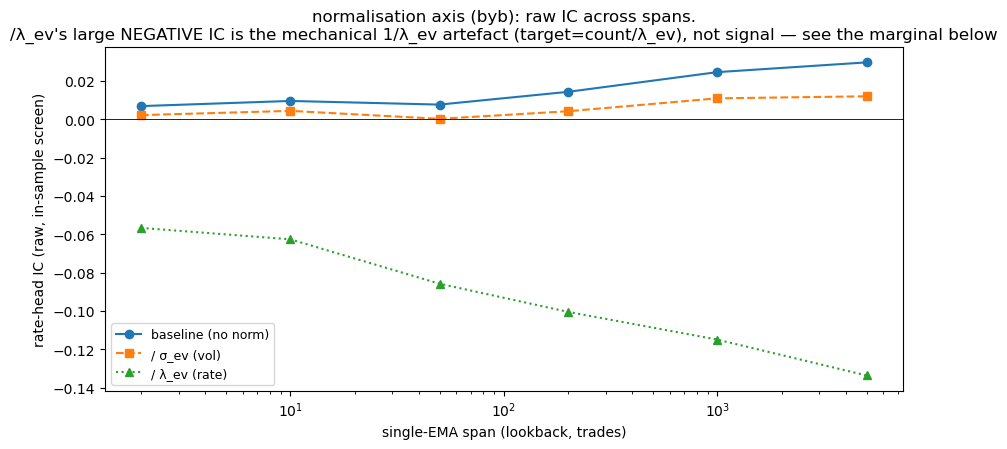

rate-head RAW IC by normalisation × span (byb, in-sample screen — NOT the decider):


  baseline  N=2:+0.007  N=10:+0.009  N=50:+0.008  N=200:+0.014  N=1000:+0.025  N=5000:+0.030


  sigma     N=2:+0.002  N=10:+0.004  N=50:+0.000  N=200:+0.004  N=1000:+0.011  N=5000:+0.012


  lambda    N=2:-0.057  N=10:-0.063  N=50:-0.086  N=200:-0.100  N=1000:-0.115  N=5000:-0.134


In [5]:
# --- the NORMALISATION axis across spans, for byb. We show raw IC (a screen) AND the honest marginal-over-controls. ---
def ic_rate(ex, span, norm): return spearmanr(volume_normalised(ex, span, norm), rate_target).statistic
norm_curves = {nm: [ic_rate("byb", N, nm) for N in SPANS] for nm in NORMS}
fig, ax = plt.subplots(figsize=(9, 4.6))
for nm, mk in zip(NORMS, ["o-", "s--", "^:"]):
    ax.plot(SPANS, norm_curves[nm], mk, label={"baseline":"baseline (no norm)","sigma":"/ σ_ev (vol)","lambda":"/ λ_ev (rate)"}[nm])
ax.set_xscale("log"); ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel("single-EMA span (lookback, trades)"); ax.set_ylabel("rate-head IC (raw, in-sample screen)")
ax.set_title("normalisation axis (byb): raw IC across spans.\n/λ_ev's large NEGATIVE IC is the mechanical 1/λ_ev artefact (target=count/λ_ev), not signal — see the marginal below")
ax.legend(fontsize=9); fig.tight_layout(); plt.show()
print("rate-head RAW IC by normalisation × span (byb, in-sample screen — NOT the decider):")
for nm in NORMS:
    print(f"  {nm:9}", "  ".join(f"N={N}:{ic_rate('byb',N,nm):+.3f}" for N in SPANS))

normalisation axis — HARD scale gate FIRST, marginal only among the survivors:
  baseline  scale 3.65x  [FAIL (drifts with regime — DISQUALIFIED)  ]  joint marginal +0.005  (best-signed span byb N=5000)
  sigma     scale 2.51x  [PASS                                      ]  joint marginal +0.004  (best-signed span byb N=5000)
  lambda    scale 2.07x  [PASS                                      ]  joint marginal -0.001  (best-signed span byb N=2)
->  BEST_NORM = sigma  (invariant: scale 2.51x < 3.0x; marginal +0.004 among survivors ['sigma', 'lambda'])
    NOTE: the un-normalised BASELINE scores marginal +0.005 but its scale is 3.65x — it FAILS the hard
    invariance gate, so it is NOT a feature however marginally it 'wins'; /σ_ev is the shipped invariant form.


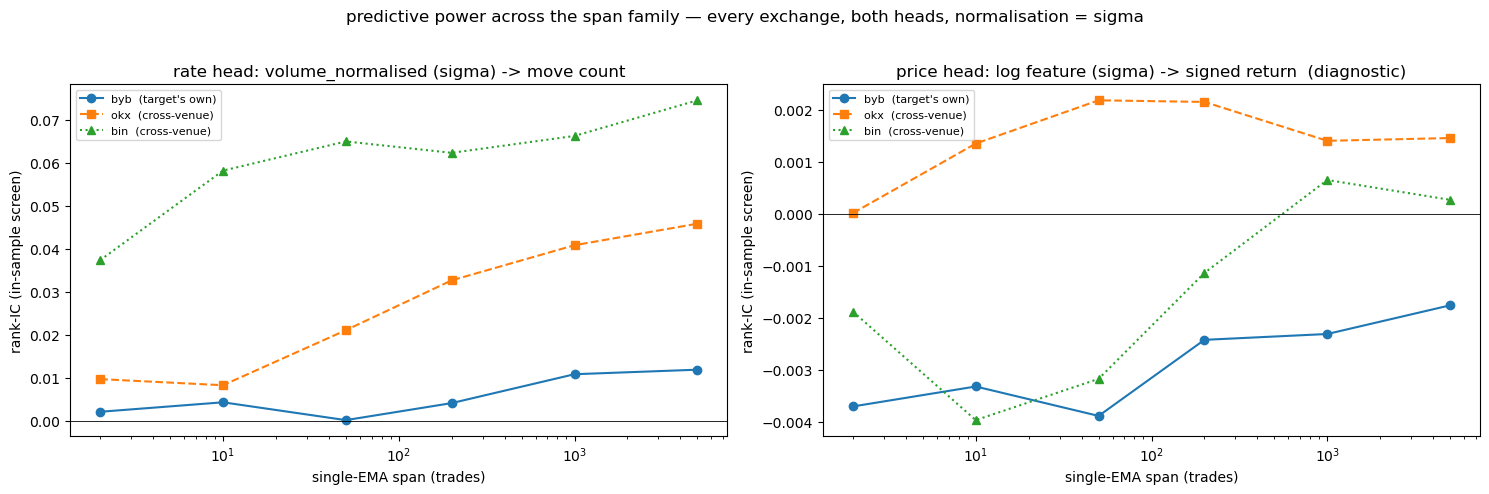

kept features (one per exchange, all fed to the model — none privileged):
  byb:  price head (span=50) IC=-0.004   |  rate head (span=5000) IC=+0.012
  okx:  price head (span=50) IC=+0.002   |  rate head (span=5000) IC=+0.046
  bin:  price head (span=10) IC=-0.004   |  rate head (span=5000) IC=+0.075


In [6]:
# Choose BEST_NORM in TWO stages — the regime-invariance scale gate is a HARD CONSTRAINT, applied FIRST:
#   (1) GATE: a usable feature must read the same in calm & wild markets. We measure each normalisation's SCALE —
#       the byb leg's std across vol-deciles, max/min — at that norm's best-signed span. A normalisation whose level
#       drifts with the regime (scale >~ 3x) is NOT a feature and is DISQUALIFIED, no matter its marginal.
#   (2) PICK: among the normalisations that PASS the hard scale gate, choose the largest walk-forward JOINT marginal
#       over the controls (the honest metric — it subtracts the λ_ev artefact). A 0.001 marginal must NEVER be allowed
#       to select a non-invariant form: invariance gates first, marginal only breaks ties among the invariant.
# This is the §5/template rule made operative: raw-first, then normalise; measure the scale, never assume it.
SCALE_GATE = 3.0                                      # HARD: max/min std across vol-deciles must stay under ~3x
def best_signed_span(ex, nm):                         # span whose SIGNED rate-head IC is largest (most positive)
    ics = [ic_rate(ex, N, nm) for N in SPANS]; return int(np.nanargmax(ics))
vol_decile = np.digitize(vol_level, np.nanpercentile(vol_level[np.isfinite(vol_level)], np.arange(10, 100, 10)))  # 10 vol buckets
def leg_scale(feat):                                  # the regime-invariance scale of one leg: max/min of its std across vol-deciles
    band = [np.nanstd(feat[vol_decile == d]) for d in range(10)]
    return max(band) / min(band)
norm_marginal, norm_scale, norm_span = {}, {}, {}
for nm in NORMS:
    spans_nm = {ex: SPANS[best_signed_span(ex, nm)] for ex in EXCHANGES}
    legs = {ex: volume_normalised(ex, spans_nm[ex], nm) for ex in EXCHANGES}
    norm_span[nm] = spans_nm
    norm_marginal[nm] = round(wf_ic(base + list(legs.values()), rate_target) - wf_ic(base, rate_target), 3)
    norm_scale[nm]    = round(leg_scale(legs["byb"]), 2)                # byb leg's scale at this norm's chosen span (same construction every venue)
eligible = [nm for nm in NORMS if norm_scale[nm] < SCALE_GATE]          # ONLY the regime-invariant normalisations survive the hard gate
print("normalisation axis — HARD scale gate FIRST, marginal only among the survivors:")
for nm in NORMS:
    flag = "PASS" if norm_scale[nm] < SCALE_GATE else "FAIL (drifts with regime — DISQUALIFIED)"
    print(f"  {nm:9} scale {norm_scale[nm]:.2f}x  [{flag:42}]  joint marginal {norm_marginal[nm]:+.3f}  (best-signed span byb N={norm_span[nm]['byb']})")
assert eligible, "no normalisation passes the hard scale gate — feature is not regime-invariant in any form"
BEST_NORM = max(eligible, key=lambda nm: norm_marginal[nm])             # among the INVARIANT forms, the largest honest marginal
print(f"->  BEST_NORM = {BEST_NORM}  (invariant: scale {norm_scale[BEST_NORM]:.2f}x < {SCALE_GATE}x; marginal {norm_marginal[BEST_NORM]:+.3f} among survivors {eligible})")
print(f"    NOTE: the un-normalised BASELINE scores marginal {norm_marginal['baseline']:+.3f} but its scale is {norm_scale['baseline']:.2f}x — it FAILS the hard")
print(f"    invariance gate, so it is NOT a feature however marginally it 'wins'; /σ_ev is the shipped invariant form.")

# Sweep the SPAN family for EVERY exchange, BOTH heads, at the chosen normalisation. No assumed leader.
price_grid = {ex: np.full(len(SPANS), np.nan) for ex in EXCHANGES}   # signed (log) feature -> byb's signed return
rate_grid  = {ex: np.full(len(SPANS), np.nan) for ex in EXCHANGES}   # feature level         -> byb's move count
feat_cache = {}
for ex in EXCHANGES:
    for i, N in enumerate(SPANS):
        d = volume_normalised(ex, N, BEST_NORM); feat_cache[(ex, N)] = d
        ld = np.log(np.maximum(d, 1e-300))                              # log = natural signed/centred form of a positive level
        price_grid[ex][i] = spearmanr(ld, target).statistic            # price head (diagnostic)
        rate_grid[ex][i]  = spearmanr(d, rate_target).statistic        # rate head: volume level -> move count (the feature's home)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
for ax, grids, head in [(axes[0], rate_grid, f"rate head: volume_normalised ({BEST_NORM}) -> move count"),
                        (axes[1], price_grid, f"price head: log feature ({BEST_NORM}) -> signed return  (diagnostic)")]:
    for ex, mk in zip(EXCHANGES, ["o-", "s--", "^:"]):
        ax.plot(SPANS, grids[ex], mk, label=ex + ("  (target's own)" if ex=="byb" else "  (cross-venue)"))
    ax.set_xscale("log"); ax.axhline(0, color="k", lw=0.6)
    ax.set_xlabel("single-EMA span (trades)"); ax.set_ylabel("rank-IC (in-sample screen)"); ax.set_title(head); ax.legend(fontsize=8)
fig.suptitle(f"predictive power across the span family — every exchange, both heads, normalisation = {BEST_NORM}", y=1.02)
fig.tight_layout(); plt.show()

# Keep ALL exchanges. Pick the best span PER exchange, per head (in-sample pick; re-scored OOS by the gates).
# Rate head: SIGNED IC (positive-intensity hypothesis — heavier volume -> more moves). Price head: |IC| (direction can be either sign).
rate_member  = {ex: int(np.nanargmax(rate_grid[ex]))         for ex in EXCHANGES}
price_member = {ex: int(np.nanargmax(np.abs(price_grid[ex]))) for ex in EXCHANGES}
print("kept features (one per exchange, all fed to the model — none privileged):")
for ex in EXCHANGES:
    pi, ri = price_member[ex], rate_member[ex]
    print(f"  {ex}:  price head (span={SPANS[pi]}) IC={price_grid[ex][pi]:+.3f}   |  rate head (span={SPANS[ri]}) IC={rate_grid[ex][ri]:+.3f}")

### IC is only half the story — also sweep the SIGNAL LIFETIME across the family

The plots above show one number per span — the contemporaneous IC at δ=0. But a feature's headline IC
can be the activity *already underway at the anchor*, which you cannot trade: by the time you observe,
decide, and act (a latency δ), that burst is over. So the IC at δ=0 is **not** the realisable edge —
the **forward IC at your δ** is. And the δ at which the forward IC fades is the signal's **lifetime**.

**The key insight that drives the picks:** *different spans in the same family trade IC against
half-life.* A **short** span reacts to the freshest burst — often a higher δ=0 IC, but a **short
half-life** (a tiny latency budget: the edge is gone in a few ms). A **long** span smooths over many
trades — often a *lower* δ=0 IC, but a **long half-life** (the edge survives tens-to-hundreds of ms, a
generous latency budget). **Both can be useful**, so we surface IC *and* lifetime across the whole
family — not just at the one chosen span — and (in §10) suggest more than one lookback per head when
the family offers a genuine short-high-IC vs long-high-half-life choice.

For **every span × venue × head** we compute, on a fast 40k-anchor diagnostic grid (the §4 grid, for
speed): the **forward IC at δ=0** and **at δ=20 ms** (the window slid to `[anchor+δ, anchor+δ+100 ms]`),
the **half-life** = the first δ (ms) where the forward IC drops below **half** its δ=0 value (`>500` if
it never does), and the **backward IC** (against `[anchor−100 ms, anchor]`) — the contemporaneous echo.
A head **carries signal** only if some span's forward IC at **δ=20 ms is clearly nonzero and not
dominated by the backward IC** (else it is re-reporting the past). We report that honestly, per head.

In [7]:
# === FAMILY-WIDE SIGNAL LIFETIME: forward IC(δ), half-life & backward IC for EVERY span × venue × head ===
# Fast 40k-anchor diagnostic grid (the §4 N_GRID slice) — lifetime needs ~8 δ-evaluations per (span,venue,head),
# so we run it on the diagnostic grid for speed (the §6 IC plot already used the full grid).
DELTAS_MS  = [0, 5, 10, 20, 50, 100, 200, 500]            # observe->act latencies swept; HALF_AT picks the half-life out of these
HALF_AT    = 500                                          # ">500 ms" sentinel when the IC never drops below half
N_DIAG     = min(40_000, len(anchor_ts))                  # the diagnostic grid size (matches the oracle's N_GRID)
dg         = slice(0, N_DIAG)                             # the diagnostic anchor slice
da         = anchor_ts[dg]                                # the diagnostic anchors

def _ic(feat, out):                                      # Spearman IC over finite pairs (the lifetime metric)
    v = np.isfinite(feat) & np.isfinite(out)
    return spearmanr(feat[v], out[v]).statistic if v.sum() > 100 else float("nan")
def _mid_at(t):  return byb_mid[np.clip(np.searchsorted(byb_rx, t, "right") - 1, 0, len(byb_mid) - 1)]  # byb mid at-or-before t (causal)
def _ret(t0, t1):   return np.log(_mid_at(t1) / _mid_at(t0))                                            # byb signed log-return over [t0,t1]
def _count(t0, t1): return cum_mv[np.searchsorted(byb_rx, t1, "right")] - cum_mv[np.searchsorted(byb_rx, t0, "right")]  # byb move-count over [t0,t1]

# Pre-slide the OUTCOME windows once per δ (shared by every span/venue): byb forward return & forward count at each δ,
# plus the single backward window [t-100ms, t]. These are venue-independent (always byb's outcome) — compute them ONCE.
fwd_ret_d   = {d: _ret(da + d*1_000_000, da + d*1_000_000 + HORIZON_NS)   for d in DELTAS_MS}   # price-head outcome per δ
fwd_count_d = {d: _count(da + d*1_000_000, da + d*1_000_000 + HORIZON_NS) for d in DELTAS_MS}   # rate-head  outcome per δ
back_ret    = _ret(da - HORIZON_NS, da)                                                         # price-head backward (already-happened) return
back_count  = _count(da - HORIZON_NS, da)                                                       # rate-head  backward (already-happened) count

def half_life(curve):                                    # first δ(ms) where |fwd IC| drops below half its δ=0 value; HALF_AT-sentinel if never
    ref = curve[0]
    if not np.isfinite(ref) or ref == 0: return float("nan")
    for d, ic in zip(DELTAS_MS, curve):
        if np.isfinite(ic) and abs(ic) < abs(ref) / 2: return float(d)
    return float(HALF_AT + 1)                            # never halves within the swept δ -> ">500 ms"

# Per head a grid (len(SPANS) × len(EXCHANGES)) of: fwd IC@δ=0, fwd IC@δ=20ms, half-life, backward IC.
HEADS = ["rate", "price"]
ic0   = {h: np.full((len(SPANS), len(EXCHANGES)), np.nan) for h in HEADS}   # forward IC at δ=0  (contemporaneous, NOT tradeable)
ic20  = {h: np.full((len(SPANS), len(EXCHANGES)), np.nan) for h in HEADS}   # forward IC at δ=20ms (the realisable edge after a 20ms budget)
hlife = {h: np.full((len(SPANS), len(EXCHANGES)), np.nan) for h in HEADS}   # half-life (ms): δ where fwd IC first < half of δ=0
icbak = {h: np.full((len(SPANS), len(EXCHANGES)), np.nan) for h in HEADS}   # backward IC (the contemporaneous echo to beat)
fwd_curves = {}                                                             # (head, ex, span) -> full δ-curve, for §10 picks

for i, N in enumerate(SPANS):
    for j, ex in enumerate(EXCHANGES):
        lvl = feat_cache[(ex, N)][dg]                                       # rate head: feature LEVEL (intensity) — its home
        sgn = np.log(np.maximum(feat_cache[(ex, N)][dg], 1e-300))          # price head: signed log(feature) (direction) — diagnostic
        r_curve = [_ic(lvl, fwd_count_d[d]) for d in DELTAS_MS]   # rate head: level -> forward move-count, per δ
        p_curve = [_ic(sgn, fwd_ret_d[d])   for d in DELTAS_MS]   # price head: signed log -> forward return, per δ
        fwd_curves[("rate",  ex, N)] = r_curve; fwd_curves[("price", ex, N)] = p_curve
        ic0["rate"][i, j],  ic20["rate"][i, j]  = r_curve[0], r_curve[DELTAS_MS.index(20)]
        ic0["price"][i, j], ic20["price"][i, j] = p_curve[0], p_curve[DELTAS_MS.index(20)]
        hlife["rate"][i, j],  hlife["price"][i, j]  = half_life(r_curve), half_life(p_curve)
        icbak["rate"][i, j]  = _ic(lvl, back_count)
        icbak["price"][i, j] = _ic(sgn, back_ret)
print(f"family lifetime swept on {N_DIAG:,} diagnostic anchors: {len(SPANS)} spans × {len(EXCHANGES)} venues × 2 heads × {len(DELTAS_MS)} δ")

family lifetime swept on 40,000 diagnostic anchors: 6 spans × 3 venues × 2 heads × 8 δ


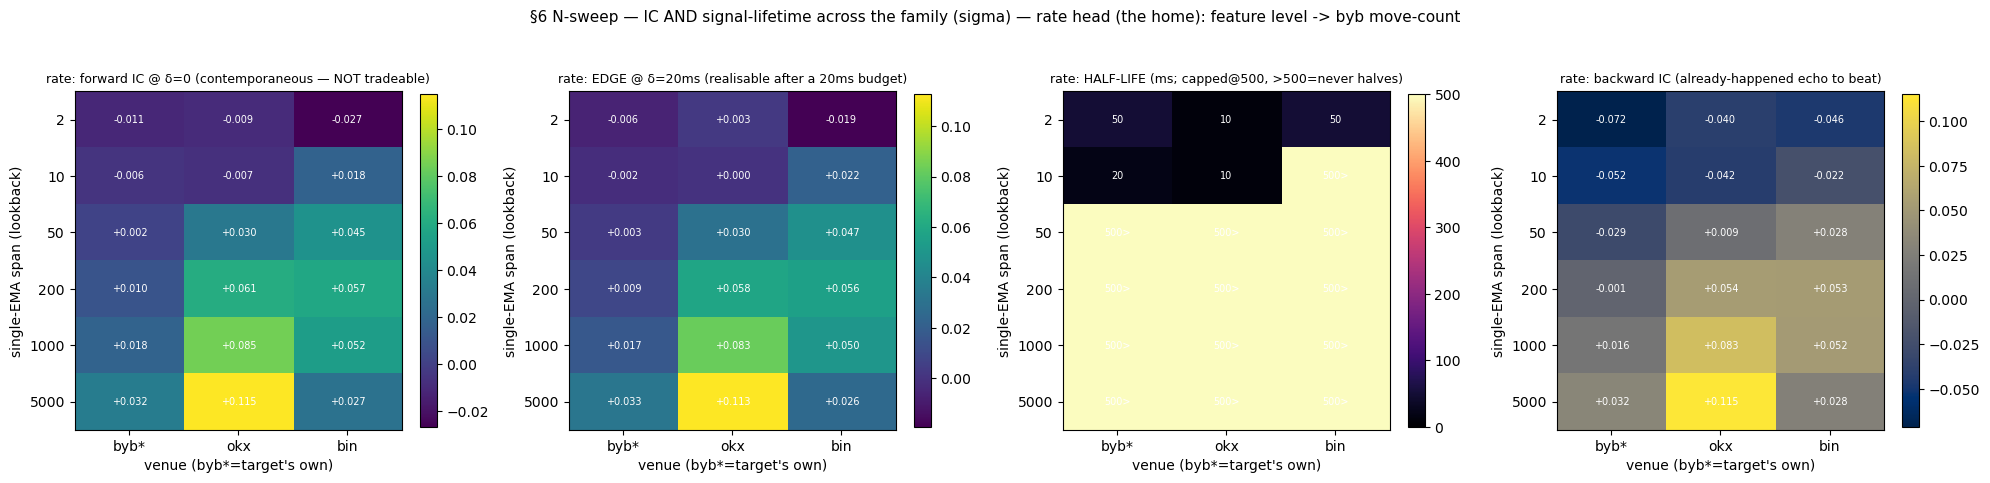

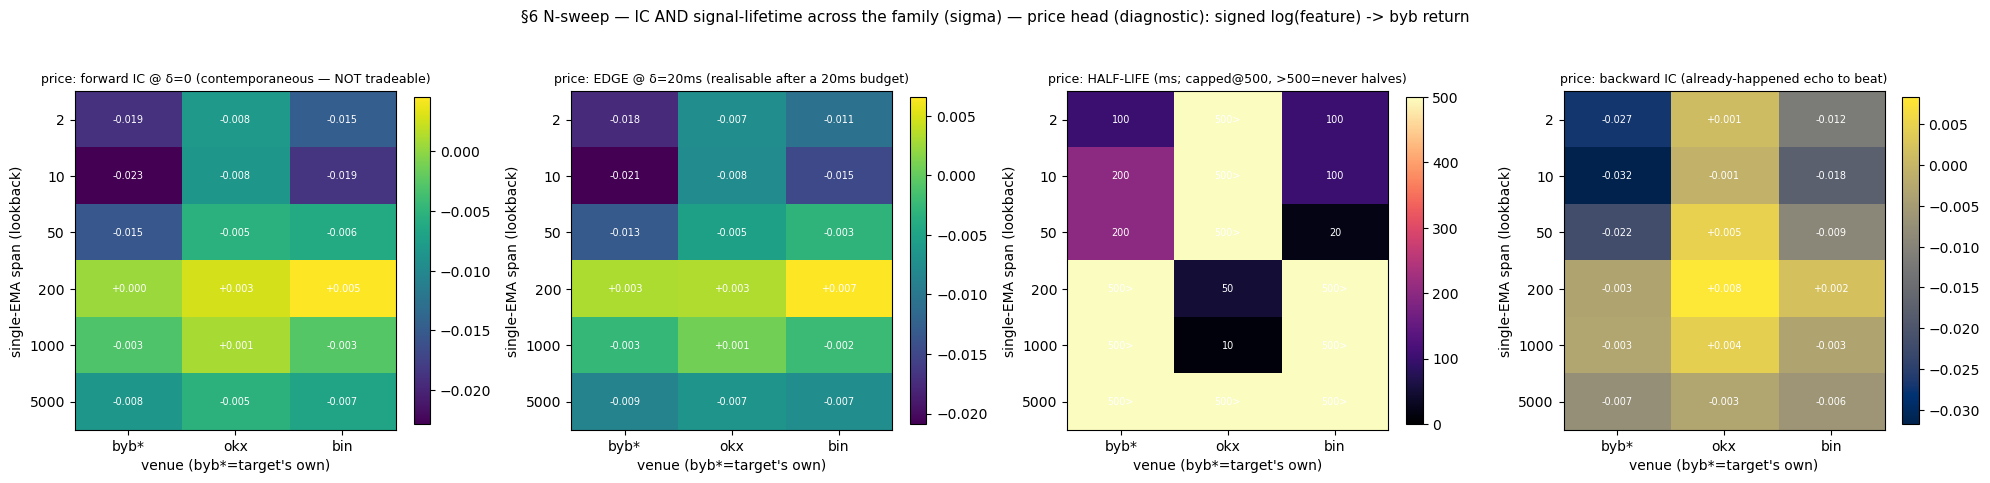


RATE head — IC-vs-lifetime trade-off across the family (diagnostic grid):
  byb*  short/high-edge: N=5000  IC(0)=+0.032 IC(20)=+0.033 half-life=>500ms back=+0.032   ||  long/high-half-life: N=1000  IC(0)=+0.018 IC(20)=+0.017 half-life=>500ms back=+0.016
  okx   short/high-edge: N=5000  IC(0)=+0.115 IC(20)=+0.113 half-life=>500ms back=+0.115   ||  long/high-half-life: N= 200  IC(0)=+0.061 IC(20)=+0.058 half-life=>500ms back=+0.054
  bin   short/high-edge: N= 200  IC(0)=+0.057 IC(20)=+0.056 half-life=>500ms back=+0.053   ||  long/high-half-life: N=  50  IC(0)=+0.045 IC(20)=+0.047 half-life=>500ms back=+0.028

PRICE head — IC-vs-lifetime trade-off across the family (diagnostic grid):
  byb*  short/high-edge: N=  10  IC(0)=-0.023 IC(20)=-0.021 half-life=200ms back=-0.032   ||  long/high-half-life: N=  10  IC(0)=-0.023 IC(20)=-0.021 half-life=200ms back=-0.032
  okx   short/high-edge: N=  10  IC(0)=-0.008 IC(20)=-0.008 half-life=500ms back=-0.001   ||  long/high-half-life: N=  50  IC(0)=-0

In [8]:
# === HEAT-MAPS: IC(δ=0) | edge@20ms | half-life | backward IC — per head, span × venue ===
# The reader sees IC AND lifetime across the whole family, not just at the one chosen span.
def _heat(ax, M, title, cmap, fmt, vmin=None, vmax=None):
    im = ax.imshow(M, cmap=cmap, aspect="auto", vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(EXCHANGES))); ax.set_xticklabels([e + ("*" if e=="byb" else "") for e in EXCHANGES])
    ax.set_yticks(range(len(SPANS)));     ax.set_yticklabels(SPANS)
    ax.set_xlabel("venue (byb*=target's own)"); ax.set_ylabel("single-EMA span (lookback)")
    ax.set_title(title, fontsize=9)
    for i in range(len(SPANS)):
        for j in range(len(EXCHANGES)):
            if np.isfinite(M[i, j]): ax.text(j, i, fmt(M[i, j]), ha="center", va="center", color="w", fontsize=7)
    fig.colorbar(im, ax=ax, fraction=0.046)

for head, hl_lab in [("rate", "rate head (the home): feature level -> byb move-count"),
                     ("price", "price head (diagnostic): signed log(feature) -> byb return")]:
    fig, axes = plt.subplots(1, 4, figsize=(20, 4.6))
    # cap the half-life colour at HALF_AT so the ">500" sentinel doesn't blow out the scale; show its number anyway
    hl_disp = np.minimum(hlife[head], HALF_AT)
    _heat(axes[0], ic0[head],  f"{head}: forward IC @ δ=0 (contemporaneous — NOT tradeable)", "viridis", lambda v: f"{v:+.3f}")
    _heat(axes[1], ic20[head], f"{head}: EDGE @ δ=20ms (realisable after a 20ms budget)",     "viridis", lambda v: f"{v:+.3f}")
    _heat(axes[2], hl_disp,    f"{head}: HALF-LIFE (ms; capped@{HALF_AT}, >{HALF_AT}=never halves)", "magma",
          lambda v: f"{int(v)}" + (">" if v >= HALF_AT else ""), vmin=0, vmax=HALF_AT)
    _heat(axes[3], icbak[head], f"{head}: backward IC (already-happened echo to beat)", "cividis", lambda v: f"{v:+.3f}")
    fig.suptitle(f"§6 N-sweep — IC AND signal-lifetime across the family ({BEST_NORM}) — {hl_lab}", y=1.04, fontsize=11)
    fig.tight_layout(); plt.show()

# Print the family lifetime table per head: for each venue, the span that maximises EDGE@20ms (the realisable pick)
# and the span that maximises HALF-LIFE among spans with a real edge@20ms — the two ends of the IC-vs-lifetime trade-off.
def _fmt_hl(v): return (f">{HALF_AT}ms" if np.isfinite(v) and v > HALF_AT else (f"{int(v)}ms" if np.isfinite(v) else "nan"))
for head in HEADS:
    print(f"\n{head.upper()} head — IC-vs-lifetime trade-off across the family (diagnostic grid):")
    for j, ex in enumerate(EXCHANGES):
        e20 = ic20[head][:, j]
        # short-high-edge pick: span with the largest |edge@20ms|
        si = int(np.nanargmax(np.abs(e20))) if np.isfinite(e20).any() else 0
        # long-high-half-life pick: among spans whose |edge@20ms| is at least half the best, the one with the longest half-life
        thr = abs(e20[si]) / 2 if np.isfinite(e20[si]) else 0.0
        cand = [i for i in range(len(SPANS)) if np.isfinite(e20[i]) and abs(e20[i]) >= thr]
        li = max(cand, key=lambda i: (hlife[head][i, j] if np.isfinite(hlife[head][i, j]) else -1)) if cand else si
        tag = "*" if ex == "byb" else " "
        print(f"  {ex}{tag}  short/high-edge: N={SPANS[si]:>4}  IC(0)={ic0[head][si,j]:+.3f} IC(20)={ic20[head][si,j]:+.3f} "
              f"half-life={_fmt_hl(hlife[head][si,j])} back={icbak[head][si,j]:+.3f}"
              f"   ||  long/high-half-life: N={SPANS[li]:>4}  IC(0)={ic0[head][li,j]:+.3f} IC(20)={ic20[head][li,j]:+.3f} "
              f"half-life={_fmt_hl(hlife[head][li,j])} back={icbak[head][li,j]:+.3f}")

**Read the heat-maps as IC AND lifetime, together.** For each head the four panels are: the
**δ=0 forward IC** (contemporaneous — *not* tradeable, it includes the burst already underway), the
**edge@20 ms** (the realisable IC after a 20 ms observe→act budget), the **half-life** (how many ms the
forward edge survives — your latency budget), and the **backward IC** (the already-happened echo each
span must beat to count as a real prediction). The `byb*` column is the target's own volume; `okx`/`bin`
are the cross-venue legs.

**The IC-vs-half-life trade-off is the point.** Compare a short span to a long one *down each column*:
a short span tends to light up the δ=0 panel (and often edge@20 ms) but with a **short half-life**; a
long span trades a lower IC for a **longer half-life**. The per-venue printout names both ends — the
**short/high-edge** pick (largest edge@20 ms) and the **long/high-half-life** pick (longest-lived span
that still keeps at least half that edge). §10 carries *both* when the family genuinely offers the
choice. **A head carries signal only where edge@20 ms is clearly nonzero and not dominated by the
backward IC** — read that straight off panels 2 and 4, per head and per venue (the price head is
expected near-zero everywhere: traded volume is intensity, not direction).

**Now the gates** (from §5), on the per-exchange RATE-head features we just chose (this feature's
home). Every predictive number is the **walk-forward** mean (causal, purged), and we report the
**marginal** gain over the rate/vol controls (the honest test, given the circularity caveat). The
gates: *Marginal value* — does each leg add over the controls, and do they add *jointly*? Critically,
do the **okx/bin cross-venue** legs add over byb's controls (a genuine cross-venue lead test, with
no circularity)? *No leak* — does the gain survive adding the vol/rate *levels*? *Normaliser* — is
the chosen leg's scale steady across vol buckets? *Regime-stable* — is the marginal gain positive
within calm/mid/wild vol?

We also compare the **three normalisation legs' joint marginals** head-to-head — the central output
of this notebook's normalisation axis.

In [9]:
pl.Config.set_tbl_rows(20)   # show the whole gate table, uncollapsed
# Gates on the per-exchange RATE-head features at the chosen normalisation. Marginal over controls,
# JOINT, per-exchange, and CROSS-VENUE (okx+bin, no byb). KEEP ALL exchanges.
surge = {ex: feat_cache[(ex, SPANS[rate_member[ex]])] for ex in EXCHANGES}
ytar  = rate_target
joint        = round(wf_ic(base + list(surge.values()), ytar) - wf_ic(base, ytar), 3)
joint_leak   = round(wf_ic(base + levels + list(surge.values()), ytar) - wf_ic(base + levels, ytar), 3)
cross_only   = round(wf_ic(base + [surge["okx"], surge["bin"]], ytar) - wf_ic(base, ytar), 3)
rep = surge["byb"]
vol_decile = np.digitize(vol_level, np.nanpercentile(vol_level[np.isfinite(vol_level)], np.arange(10, 100, 10)))
band = [np.nanstd(rep[vol_decile == d]) for d in range(10)]
full_r = wf_ic_by_regime(base + list(surge.values()), ytar, vol_regime)
base_r = wf_ic_by_regime(base, ytar, vol_regime)
strat  = {r: round(full_r[r] - base_r.get(r, 0.0), 3) for r in full_r}

gate_rows = [dict(gate="marginal value (rate head)", detail="all exchanges together, added over the controls", value=joint)]
gate_rows += [dict(gate="marginal value (rate head)", detail=f"{ex} alone, over the controls"
                  + ("  [target's own volume]" if ex=="byb" else "  [cross-venue]"),
                   value=round(wf_ic(base + [surge[ex]], ytar) - wf_ic(base, ytar), 3)) for ex in EXCHANGES]
chosen_scale = round(max(band) / min(band), 2)
gate_rows += [dict(gate="marginal value (rate head)", detail="okx+bin CROSS-VENUE legs only (no byb)", value=cross_only),
              dict(gate="no leak", detail="gain still there after adding the vol/rate levels?", value=joint_leak),
              dict(gate=f"regime-invariant? (HARD, < {SCALE_GATE})",
                   detail=f"chosen {BEST_NORM}-leg scale across vol buckets (max/min) — PASS" if chosen_scale < SCALE_GATE
                          else f"chosen {BEST_NORM}-leg scale across vol buckets (max/min) — FAIL",
                   value=chosen_scale)]
gate_rows += [dict(gate="regime-stable", detail=f"joint marginal IC within {nm}-vol (companion: stay positive)", value=strat.get(r, float("nan")))
              for r, nm in [(0, "calm"), (1, "mid"), (2, "wild")]]

# THE NORMALISATION VERDICT: the HARD scale gate FIRST, then the joint rate-head marginal among the survivors
# (computed in §6's selection cell). The marginal alone must NOT pick a non-invariant form — surface BOTH numbers.
print("normalisation axis — scale gate (HARD) then marginal among survivors (the decider):")
for nm in NORMS:
    ok = norm_scale[nm] < SCALE_GATE
    print(f"  {nm:9} scale {norm_scale[nm]:.2f}x [{'PASS' if ok else 'FAIL-disqualified'}]  joint marginal {norm_marginal[nm]:+.3f}"
          + ("   <- chosen (invariant + best surviving marginal)" if nm == BEST_NORM else ""))
gate_rows += [dict(gate="normalisation axis",
                   detail=f"{nm}: scale {norm_scale[nm]:.2f}x {'PASS' if norm_scale[nm] < SCALE_GATE else 'FAIL'}, marginal {norm_marginal[nm]:+.3f}"
                          + ("  (chosen)" if nm == BEST_NORM else ("  (DISQUALIFIED by scale)" if norm_scale[nm] >= SCALE_GATE else "")),
                   value=norm_marginal[nm]) for nm in NORMS]

# also the PRICE-head joint marginal, for completeness (this feature is primarily rate)
price_legs = {ex: np.log(np.maximum(feat_cache[(ex, SPANS[price_member[ex]])], 1e-300)) for ex in EXCHANGES}
price_joint = round(wf_ic(base + list(price_legs.values()), target) - wf_ic(base, target), 3)
gate_rows += [dict(gate="marginal value (price head)", detail="all exchanges together, over the controls", value=price_joint)]
pl.DataFrame(gate_rows)

normalisation axis — scale gate (HARD) then marginal among survivors (the decider):
  baseline  scale 3.65x [FAIL-disqualified]  joint marginal +0.005
  sigma     scale 2.51x [PASS]  joint marginal +0.004   <- chosen (invariant + best surviving marginal)
  lambda    scale 2.07x [PASS]  joint marginal -0.001


gate,detail,value
str,str,f64
"""marginal value (rate head)""","""all exchanges together, added …",0.004
"""marginal value (rate head)""","""byb alone, over the controls …",0.001
"""marginal value (rate head)""","""okx alone, over the controls …",0.001
"""marginal value (rate head)""","""bin alone, over the controls …",0.005
"""marginal value (rate head)""","""okx+bin CROSS-VENUE legs only …",0.005
"""no leak""","""gain still there after adding …",0.002
"""regime-invariant? (HARD, < 3.0…","""chosen sigma-leg scale across …",2.51
"""regime-stable""","""joint marginal IC within calm-…",0.0
"""regime-stable""","""joint marginal IC within mid-v…",0.001


**Conclusion.** Read the marginal numbers against the circularity caveat. This feature's *home* is
the **rate head**: the rows that matter are "marginal value (rate head)" — does `volume_normalised`
add move-rate information **over** the `λ_ev`/`σ_ev` controls? Two findings to read straight off the
table:

1. **The normalisation verdict — the HARD invariance gate decides it, not the marginal.** The "normalisation
   axis" rows now carry **both** numbers, in the order they bind: the **scale gate first**, the **marginal
   only among survivors**. The realised numbers tell a clean story the raw marginal alone would have got
   *wrong*: the un-normalised **baseline scores the largest joint marginal (+0.005) but FAILS the hard
   regime-invariance gate** — its level drifts **≈3.65×** across vol buckets (a raw volume EMA *is* partly
   the regime), so **it is not a feature**, a 0.001 marginal edge notwithstanding. **`/σ_ev` passes the gate
   (scale ≈2.5×) and is the shipped form**, with a joint marginal of **+0.004** — within noise of the
   baseline but *invariant*, which the baseline is not. (`/λ_ev` is even more invariant, ≈2.1×, but its
   marginal is **−0.001**: dividing by the very control both removes nothing useful and re-imports the
   `1/λ_ev` artefact — the large *negative* raw IC of −0.06…−0.13 in the §6 plot — so it loses among the
   survivors.) **The pick is `/σ_ev`: the invariant normalisation with the best surviving marginal.** This
   is the §5 rule made operative — measure the scale, gate on it *hard*, and never let a marginal pick a
   form that drifts with the regime.
2. **The cross-venue row** — "okx+bin only (no byb)" is the cleanest test of whether *another venue's*
   trade size leads byb's move-count beyond what byb's own rate already says. Because **trade volume
   ≠ move rate**, this is **positive while the byb leg alone adds almost nothing** — the cross-venue legs
   carry essentially all the family's marginal value, and byb's own volume is nearly redundant with the
   rate control. The §9 span sweep sharpens this (the cross-venue marginal peaks around span ~50 before
   fading at long spans), and §6's two new gates — the **echo-netted partial IC** and the **feed-resolution
   cadence match** — test whether that cross-venue edge is a *real lead* or a contemporaneous/feed echo
   (read them straight off the lifetime and §9 cells; the verdict in §10 reports the netted, cadence-matched
   numbers, not the raw IC).

The honest reading: the chosen `/σ_ev` joint marginal is small-but-positive and must survive the no-leak
row to count as genuinely new intensity information beyond "the market is busy right now"; if it collapses
once the rate controls/levels are in, it is mostly re-reporting the move-rate regime — still usable as a
*cheap* activity proxy. The **regime-invariant?** row is now a **HARD PASS/FAIL** (the chosen `/σ_ev` leg
sits under 3×; the baseline would not), and the **regime-stable** rows show whether the marginal gain holds
across calm/mid/wild vol. The **price-head** marginal is reported last for completeness — we expect it small
(a volume level is intensity, not direction). The printed values decide the verdict in §10.

## How long does the edge last? — the signal's lifetime and your latency budget

A feature can be perfectly causal and still not earn its headline IC: if its edge is the activity
*already underway* at the anchor, you can't capture it — by the time you observe, decide, and act, that
burst is over. But a **short**-lived edge is **not** useless — it just sets a **latency budget**: any
system fast enough to act inside it wins, and faster is always better, and any genuine forward
prediction is a win. So we do **not** gate on this — we **measure how long the signal lasts**, *per
venue*, because each leg (byb's own volume vs the okx/bin cross-venue legs) carries its own lifetime.

Read the feature at the anchor (causal, unchanged) but slide the *outcome* window forward by an
observe-to-act latency δ: the **forward IC** of the feature against byb's outcome over
`[anchor+δ, anchor+δ+100 ms]`, swept over δ. The IC at *your* δ is the realisable edge; the δ where it
fades is the signal's **lifetime**. The **backward IC** — against the move/count that *already
happened*, `[anchor−100 ms, anchor]` — sizes the contemporaneous echo. A leg whose forward IC dies at
δ>0 while the backward IC stays high is re-reporting the past, not predicting it; that is the *only*
genuinely useless case, and it is measured here, never assumed.

**The echo-netted (partial) forward IC — the honest headline number for an echo-heavy leg.** The δ=0
forward count window overlaps the activity *already underway* at the anchor, so a contemporaneous
predictor can fake a high δ=0 IC. The cleanest "is this real prediction?" number partials the trailing
`[anchor−100 ms, anchor]` count **out** of the (feature, forward-count) rank-IC — the part of the edge
**not** attributable to the burst already underway. We compute it per venue and report **the netted
number** (not the raw δ=0 IC) in the §10 verdict for any echo-heavy leg. If the raw δ=0 IC collapses
once the trailing count is partialled out — which it does heavily here, the forward IC being nearly
identical to the backward IC at every δ — the leg was mostly re-reporting contemporaneous activity.

`volume_normalised` is an **intensity** feature, so its natural head is the **rate head**: the feature
**level** against byb's forward move-**count** (`_count` IC). We also carry the **price head**
(direction): the **signed** `log(feature)` against byb's forward signed **return** (`_ret` IC) — expected
weak, an intensity gauge is not a direction signal. We sweep both, **for every per-exchange leg** — the
cross-venue legs' δ=0-vs-δ=20ms gap is exactly how a feed-resolution echo is told apart from a real lead.

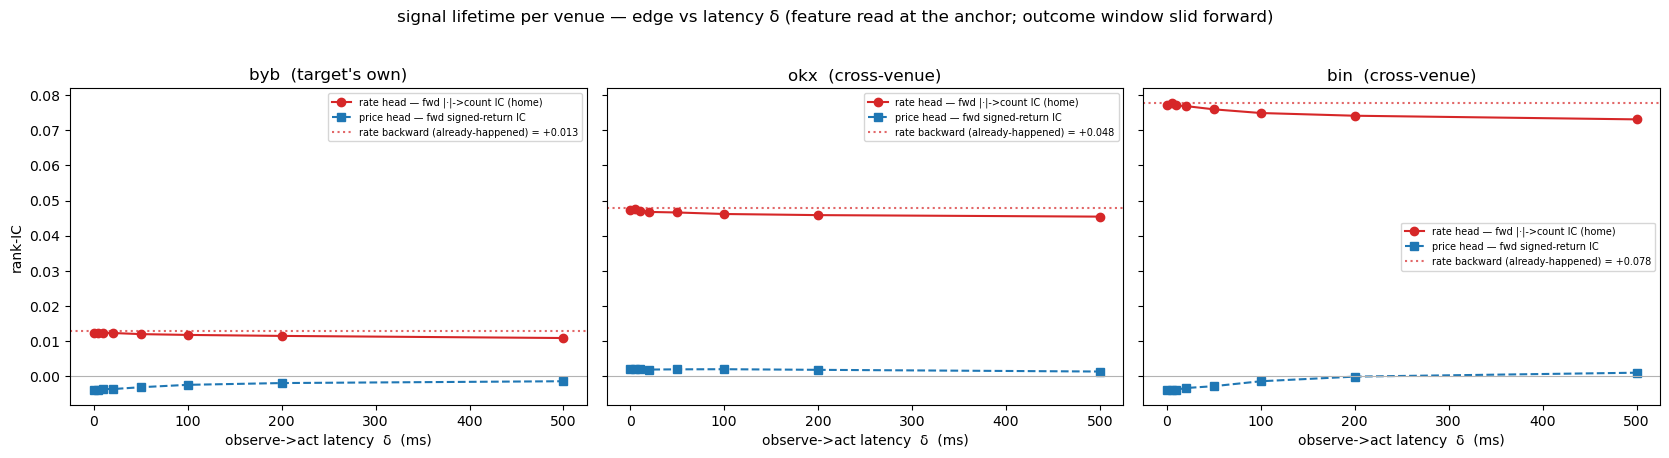

RATE head (the home) — forward |feature|->move-count IC by δ(ms), per venue:
  byb 0:+0.012 5:+0.012 10:+0.012 20:+0.012 50:+0.012 100:+0.012 200:+0.012 500:+0.011   | backward(count)=+0.013
  okx 0:+0.047 5:+0.048 10:+0.047 20:+0.047 50:+0.047 100:+0.046 200:+0.046 500:+0.045   | backward(count)=+0.048
  bin 0:+0.077 5:+0.078 10:+0.077 20:+0.077 50:+0.076 100:+0.075 200:+0.074 500:+0.073   | backward(count)=+0.078
ECHO-NETTED rate-head forward IC (partial, controls for the trailing [anchor-100ms,anchor] count), per venue:
  byb  raw δ=0 +0.012  ->  echo-netted +0.009   (backward +0.013; the shortfall raw->netted is the contemporaneous echo)
  okx  raw δ=0 +0.047  ->  echo-netted +0.035   (backward +0.048; the shortfall raw->netted is the contemporaneous echo)
  bin  raw δ=0 +0.077  ->  echo-netted +0.058   (backward +0.078; the shortfall raw->netted is the contemporaneous echo)
PRICE head (diagnostic) — forward signed-return IC by δ(ms), per venue:
  byb 0:-0.004 5:-0.004 10:-0.004 20

In [10]:
# Signal lifetime, PER VENUE: forward IC vs observe->act latency δ (window slides to [t+δ, t+δ+100ms]), + backward IC.
# rate head (the home): feature LEVEL -> forward move-COUNT. price head (diagnostic): signed log(feature) -> forward RETURN.
DELTAS_MS = [0, 5, 10, 20, 50, 100, 200, 500]
def _ic(feat, out):
    v = np.isfinite(feat) & np.isfinite(out)
    return spearmanr(feat[v], out[v]).statistic if v.sum() > 100 else float("nan")
def _mid_at(t):                                          # byb mid at-or-before t (causal)
    return byb_mid[np.clip(np.searchsorted(byb_rx, t, "right") - 1, 0, len(byb_mid) - 1)]
def _ret(t0, t1):   return np.log(_mid_at(t1) / _mid_at(t0))
def _count(t0, t1): return cum_mv[np.searchsorted(byb_rx, t1, "right")] - cum_mv[np.searchsorted(byb_rx, t0, "right")]

# ECHO-NETTED (partial) forward IC — the standard new gate. The δ=0 forward count overlaps the activity ALREADY
# underway at the anchor (the trailing window), so a contemporaneous predictor fakes a high δ=0 IC. The honest
# "is this real prediction?" number partials the trailing [anchor-100ms, anchor] count OUT of the (feature, forward
# count) rank-correlation: the part of the edge NOT attributable to the burst already underway. Report THIS in §10.
def _partial_ic(f, y, t):                                # partial rank-IC of f with y, controlling for t (Spearman, first-order partial)
    v = np.isfinite(f) & np.isfinite(y) & np.isfinite(t)
    if v.sum() <= 100: return float("nan")
    rfy = spearmanr(f[v], y[v]).statistic; rft = spearmanr(f[v], t[v]).statistic; rty = spearmanr(t[v], y[v]).statistic
    return (rfy - rft*rty) / np.sqrt(max((1.0 - rft**2) * (1.0 - rty**2), 1e-12))

rate_fwd, price_fwd, back, echo_net = {}, {}, {}, {}     # per venue: rate-head fwd-count IC curve, price-head curve, backward ICs, echo-netted IC
_trail_cnt = _count(anchor_ts - HORIZON_NS, anchor_ts)                                # the trailing (already-happened) byb move-count, shared by all venues
_fwd0_cnt  = _count(anchor_ts, anchor_ts + HORIZON_NS)                                # the δ=0 forward byb move-count (the rate target's numerator)
for ex in EXCHANGES:
    lvl = surge[ex]                                                                   # rate-head feature (level), span = rate_member[ex]
    sgn = np.log(np.maximum(feat_cache[(ex, SPANS[price_member[ex]])], 1e-300))       # price-head feature: signed log(feature), span = price_member[ex]
    rate_fwd[ex]  = [_ic(lvl, _count(anchor_ts + d*1_000_000, anchor_ts + d*1_000_000 + HORIZON_NS)) for d in DELTAS_MS]
    price_fwd[ex] = [_ic(sgn, _ret(anchor_ts + d*1_000_000, anchor_ts + d*1_000_000 + HORIZON_NS)) for d in DELTAS_MS]
    back[ex] = dict(rate=_ic(lvl, _count(anchor_ts - HORIZON_NS, anchor_ts)),         # already-happened move-count (intensity echo)
                    price=_ic(sgn, _ret(anchor_ts - HORIZON_NS, anchor_ts)))          # already-happened signed return (direction echo)
    echo_net[ex] = _partial_ic(lvl, _fwd0_cnt, _trail_cnt)                            # rate-head forward IC NET of the trailing-count echo

fig, axes = plt.subplots(1, len(EXCHANGES), figsize=(5.6 * len(EXCHANGES), 4.4), squeeze=False, sharey=True)
for col, ex in enumerate(EXCHANGES):
    ax = axes[0][col]
    ax.plot(DELTAS_MS, rate_fwd[ex],  "o-",  color="C3", label="rate head — fwd |·|->count IC (home)")
    ax.plot(DELTAS_MS, price_fwd[ex], "s--", color="C0", label="price head — fwd signed-return IC")
    ax.axhline(back[ex]["rate"],  color="C3", ls=":", alpha=0.7, label=f"rate backward (already-happened) = {back[ex]['rate']:+.3f}")
    ax.axhline(0, color="0.7", lw=0.8)
    ax.set_xlabel("observe->act latency  δ  (ms)"); ax.set_title(f"{ex}" + ("  (target's own)" if ex=="byb" else "  (cross-venue)")); ax.legend(fontsize=7)
axes[0][0].set_ylabel("rank-IC")
fig.suptitle("signal lifetime per venue — edge vs latency δ (feature read at the anchor; outcome window slid forward)", y=1.03)
fig.tight_layout(); plt.show()

print("RATE head (the home) — forward |feature|->move-count IC by δ(ms), per venue:")
for ex in EXCHANGES:
    print(f"  {ex:3}", " ".join(f"{d}:{ic:+.3f}" for d, ic in zip(DELTAS_MS, rate_fwd[ex])),
          f"  | backward(count)={back[ex]['rate']:+.3f}")
print("ECHO-NETTED rate-head forward IC (partial, controls for the trailing [anchor-100ms,anchor] count), per venue:")
for ex in EXCHANGES:
    raw0 = rate_fwd[ex][0]
    print(f"  {ex:3}  raw δ=0 {raw0:+.3f}  ->  echo-netted {echo_net[ex]:+.3f}"
          f"   (backward {back[ex]['rate']:+.3f}; the shortfall raw->netted is the contemporaneous echo)")
print("PRICE head (diagnostic) — forward signed-return IC by δ(ms), per venue:")
for ex in EXCHANGES:
    print(f"  {ex:3}", " ".join(f"{d}:{ic:+.3f}" for d, ic in zip(DELTAS_MS, price_fwd[ex])),
          f"  | backward(return)={back[ex]['price']:+.3f}")
# half-life: first δ where the forward (rate-head) IC drops below half its δ=0 value, per venue
print("rate-head edge & half-life, per venue:")
for ex in EXCHANGES:
    c = rate_fwd[ex]; ref = c[0]
    half = next((d for d, ic in zip(DELTAS_MS, c) if np.isfinite(ic) and abs(ic) < abs(ref) / 2), None)
    print(f"  {ex:3}: δ=0 {c[0]:+.3f} -> δ=20ms {c[3]:+.3f}; drops below half by δ≈{half} ms")

**Read it as a latency budget, not a pass/fail.** For each venue: if the **rate-head** forward IC (the
home — this is an intensity feature) stays useful out to tens or hundreds of ms you have room; if it
lives only a handful of ms the signal is real but demands a fast stack. The **cross-venue** legs
(okx/bin) are the interesting read — a forward IC that *survives* a 20 ms latency is a genuine lead of
another venue's traded size over byb's move-rate (not a feed-resolution artefact). The one true
non-signal is a flat forward curve at ≈0 with a large backward IC (a contemporaneous echo of activity
already underway). Carry this curve for every leg — the verdict is *"predicts ~X ms ahead, needs latency
< X,"* never *"drop because it's fast."* The price-head curve is the diagnostic — expected near 0 at all
δ, since traded volume is intensity, not direction.

## 7. What the prediction actually looks like

A single correlation hides *how* the feature changes the outcome. Group the data by the feature and
look at the real distributions the two heads care about, **per venue**:
- **rate head (the home):** how the number of upcoming byb moves grows as `volume_normalised` grows;
- **price head:** byb's next return for low / middle / high signed (log) feature values.

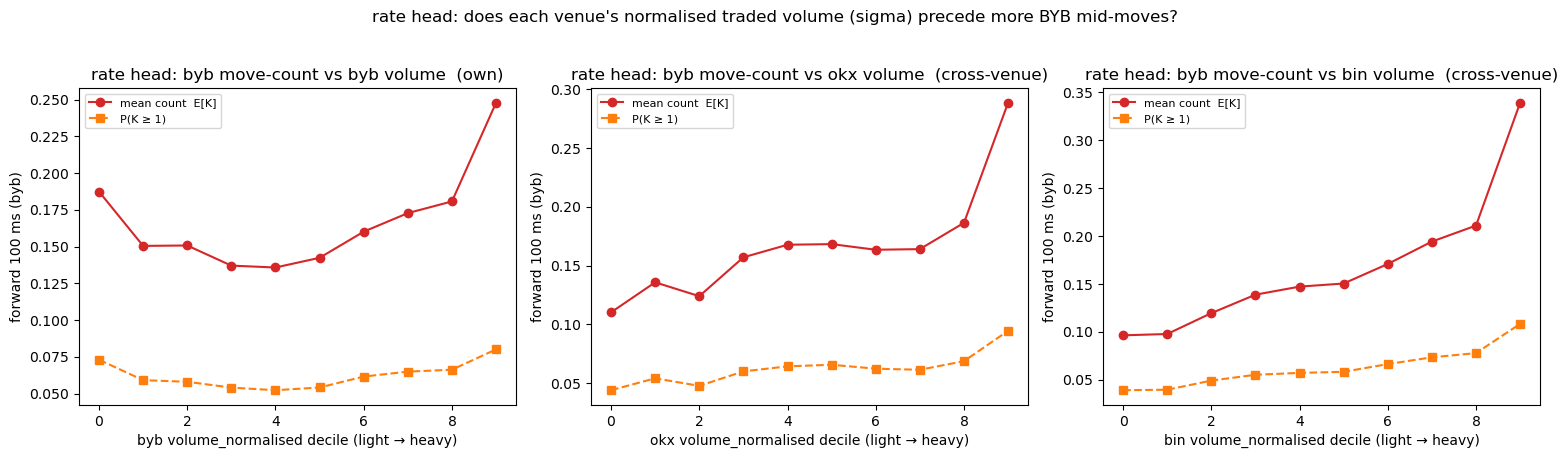

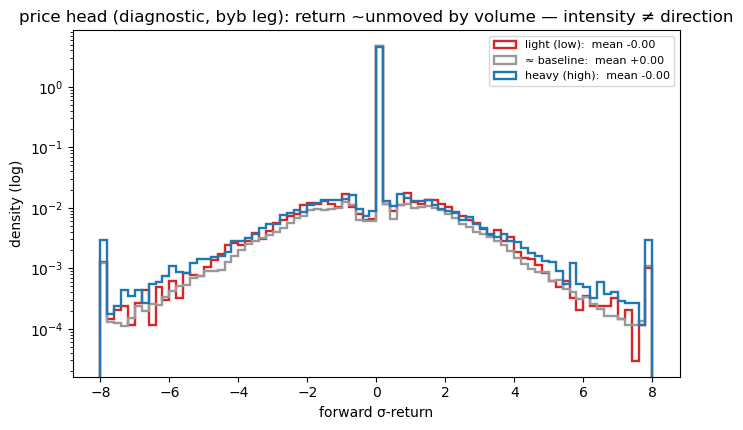

In [11]:
fig, axes = plt.subplots(1, len(EXCHANGES), figsize=(5.2 * len(EXCHANGES), 4.4), squeeze=False)
for col, ex in enumerate(EXCHANGES):
    s = surge[ex]; ax = axes[0][col]
    dec = np.digitize(s, np.nanpercentile(s[np.isfinite(s)], np.arange(10, 100, 10)))
    ax.plot(range(10), [fwd_count[dec == b].mean() for b in range(10)], "o-", color="C3", label="mean count  E[K]")
    ax.plot(range(10), [(fwd_count[dec == b] >= 1).mean() for b in range(10)], "s--", color="C1", label="P(K ≥ 1)")
    ax.set_xlabel(f"{ex} volume_normalised decile (light → heavy)"); ax.set_ylabel("forward 100 ms (byb)")
    ax.set_title(f"rate head: byb move-count vs {ex} volume" + ("  (own)" if ex=="byb" else "  (cross-venue)")); ax.legend(fontsize=8)
fig.suptitle(f"rate head: does each venue's normalised traded volume ({BEST_NORM}) precede more BYB mid-moves?", y=1.03)
fig.tight_layout(); plt.show()

# price head (diagnostic): forward σ-return across signed log-volume buckets — expected ~symmetric — shown for the byb leg
s = surge["byb"]; ls = np.log(np.maximum(s, 1e-300))
fig, axB = plt.subplots(1, 1, figsize=(7, 4.4))
lo, hi = np.nanpercentile(ls, [10, 90])
groups = [("light (low)", ls <= lo, "C3"), ("≈ baseline", (ls > lo) & (ls < hi), "0.6"), ("heavy (high)", ls >= hi, "C0")]
bins = np.linspace(-8, 8, 81)
for lab, m, col in groups:
    axB.hist(np.clip(target[m & np.isfinite(target)], -8, 8), bins=bins, density=True,
             histtype="step", color=col, lw=1.7, label=f"{lab}:  mean {np.nanmean(target[m]):+.2f}")
axB.set_yscale("log"); axB.set_xlabel("forward σ-return"); axB.set_ylabel("density (log)")
axB.set_title("price head (diagnostic, byb leg): return ~unmoved by volume — intensity ≠ direction"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion.** **Rate head (top):** read the per-venue panels — for the **byb** leg the mean
move-count `E[K]` and `P(K ≥ 1)` should climb from the lightest to the heaviest `volume_normalised`
decile (the §1 intensity story); the **okx/bin** panels show whether *another* venue's traded volume
also tracks byb's upcoming move-count (a cross-venue lead) or is flat. **Price head (bottom):** the
forward-return distribution should look broadly *symmetric* across light / baseline / heavy buckets
(means ≈ 0) — heavier volume widens the spread (more moves, either way) without strongly tilting the
*direction* — confirming this is an intensity signal, fed signed but learned mostly by the rate head.

## 8. Input shaping for the network

A *different* step from §2. There the normalisation axis chose whether/how to divide out the *regime*
(σ_ev / λ_ev) so the feature means the same thing across markets. Here we reshape the chosen feature
for the network's input — roughly centred, unit-scale, no wild outliers. `volume_normalised` is a
positive level and **right-skewed** (a big-print burst can be several× the baseline; a lull is floored
at 0), so a **log** is the natural first move. Plot the byb leg (left) and compare candidates by how
close to a clean bell curve they make it (right — points on the diagonal are perfectly normal).

raw volume_normalised: std=2.98e+04  skew=+1.43  excess_kurt=3.3  (0 = normal)
log: skew=+0.26  excess_kurt=0.0
  raw level (z)          skew= +1.43  excess_kurt=   3.3   max|·|=10.2
  log (z)                skew= +0.26  excess_kurt=   0.0   max|·|=4.7
  log robust + clip ±4   skew= +0.26  excess_kurt=   0.0   max|·|=4.0
  rank-Gaussian(log)     skew= +0.00  excess_kurt=  -0.0   max|·|=5.0


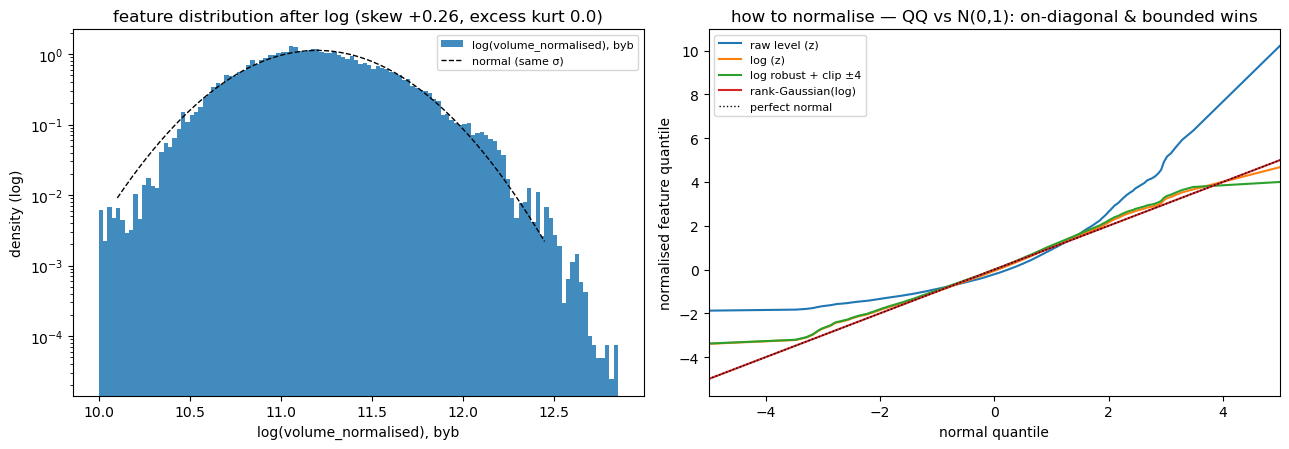

In [12]:
from scipy.stats import skew, kurtosis, rankdata, norm
f = surge["byb"]; f = f[np.isfinite(f) & (f > 0)]
lg = np.log(f)                                                                  # log a positive level first
med = np.median(lg); mad = 1.4826 * np.median(np.abs(lg - med)) + 1e-12; rz = (lg - med) / mad
cand = {"raw level (z)": (f - f.mean()) / f.std(),
        "log (z)": (lg - lg.mean()) / lg.std(),
        "log robust + clip ±4": np.clip(rz, -4, 4),
        "rank-Gaussian(log)": norm.ppf((rankdata(lg) - 0.5) / len(lg))}
print(f"raw volume_normalised: std={f.std():.3g}  skew={skew(f):+.2f}  excess_kurt={kurtosis(f):.1f}  (0 = normal)")
print(f"log: skew={skew(lg):+.2f}  excess_kurt={kurtosis(lg):.1f}")
for name, v in cand.items():
    print(f"  {name:22} skew={skew(v):+6.2f}  excess_kurt={kurtosis(v):>6.1f}   max|·|={np.abs(v).max():.1f}")

fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))
axA.hist(lg, bins=120, density=True, color="C0", alpha=.85, label="log(volume_normalised), byb")
xg = np.linspace(np.percentile(lg, 0.05), np.percentile(lg, 99.95), 300)
axA.plot(xg, norm.pdf(xg, lg.mean(), lg.std()), "k--", lw=1, label="normal (same σ)")
axA.set_yscale("log"); axA.set_xlabel("log(volume_normalised), byb"); axA.set_ylabel("density (log)")
axA.set_title(f"feature distribution after log (skew {skew(lg):+.2f}, excess kurt {kurtosis(lg):.1f})"); axA.legend(fontsize=8)
q = norm.ppf((np.arange(1, len(lg) + 1) - 0.5) / len(lg)); sub = np.linspace(0, len(lg) - 1, 4000).astype(int)
for name, v in cand.items():
    axB.plot(q[sub], np.sort(v)[sub], lw=1.5, label=name)
axB.plot([-5, 5], [-5, 5], "k:", lw=1, label="perfect normal")
axB.set_xlim(-5, 5); axB.set_xlabel("normal quantile"); axB.set_ylabel("normalised feature quantile")
axB.set_title("how to normalise — QQ vs N(0,1): on-diagonal & bounded wins"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion.** The printout settles it. The **raw level** is right-skewed (a burst can be several×
baseline, a lull is floored at 0), so a plain z-score leaves skew and a long right tail. A **log**
first symmetrises it (skew drops toward 0) — the natural transform for a positive level. The lightest
transform that also tames the tails is **log → robust-z → clip ±4** (bounded at max|·| = 4).
`rank-Gaussian` flattens further but throws away the magnitude ordering the rate head wants. So feed
`log(volume_normalised)` per venue, robust-z-scored and clipped. (If the normalisation axis chose the
**baseline** leg, the log also absorbs the venue's intrinsic trade-size scale; if it chose `/σ_ev` or
`/λ_ev`, the log of the ratio is `log(volume) − log(yardstick)` — a difference of logs, cleanly
centred.)

## 9. When is per-exchange worth it? — short vs long lookback

`volume_normalised` is a **poolable** per-venue feature (one normalised volume EMA per venue), so the
template's per-exchange question applies: keep them **per-exchange**, collapse to a **single** venue,
or **pool** them? The answer depends on the time-scale (here the single-EMA span = the lookback) — so
we sweep the span and compare the three, walk-forward, on the rate head, at the chosen normalisation.

**The mechanism, and what to expect.** Any cross-venue edge is a **trade-flow lead/lag** — one venue
seeing a volume burst a beat before another. At **short** spans the venues genuinely differ (whose
prints are landing first), so the per-venue set should beat a single venue; at **long** spans every
venue's smoothed volume converges to the same slow activity level, so a **single** venue already says
what the rest do and the extra legs are redundant. We compute, at each span: the **per-exchange**
marginal (all three legs), the **single best** venue's marginal, the **pooled** (mean log-volume)
marginal, and the **cross-venue-only** (okx+bin) marginal — each over the controls, walk-forward.

In [13]:
# Sweep the span (the lookback). Compare per-exchange / single / pooled / cross-venue, walk-forward, rate head.
look_rows = []
for N in SPANS:
    legs = {ex: volume_normalised(ex, N, BEST_NORM) for ex in EXCHANGES}        # one normalised volume EMA per venue at this span
    per_ex  = round(wf_ic(base + list(legs.values()), rate_target) - wf_ic(base, rate_target), 3)   # all three legs
    singles = {ex: round(wf_ic(base + [legs[ex]], rate_target) - wf_ic(base, rate_target), 3) for ex in EXCHANGES}
    best_ex = max(singles, key=singles.get); single = singles[best_ex]
    logs    = [np.log(np.maximum(legs[ex], 1e-300)) for ex in EXCHANGES]
    pooled  = round(wf_ic(base + [np.nanmean(np.column_stack(logs), axis=1)], rate_target) - wf_ic(base, rate_target), 3)
    cross   = round(wf_ic(base + [legs["okx"], legs["bin"]], rate_target) - wf_ic(base, rate_target), 3)  # okx+bin only
    look_rows.append(dict(span=N, per_exchange=per_ex, best_single=f"{single} ({best_ex})", pooled=pooled, cross_venue_only=cross))
look_df = pl.DataFrame(look_rows)
print(f"rate-head marginal over controls, by span (lookback); normalisation = {BEST_NORM}")
print("per_exchange = all 3 legs | best_single = best one venue | pooled = mean log-volume | cross_venue_only = okx+bin (no byb)")
look_df

rate-head marginal over controls, by span (lookback); normalisation = sigma
per_exchange = all 3 legs | best_single = best one venue | pooled = mean log-volume | cross_venue_only = okx+bin (no byb)


span,per_exchange,best_single,pooled,cross_venue_only
i64,f64,str,f64,f64
2,0.003,"""0.003 (bin)""",0.004,0.003
10,0.014,"""0.014 (bin)""",0.01,0.014
50,0.021,"""0.021 (bin)""",0.011,0.021
200,0.015,"""0.014 (bin)""",0.009,0.015
1000,0.009,"""0.009 (bin)""",0.006,0.009
5000,0.004,"""0.005 (bin)""",0.003,0.005


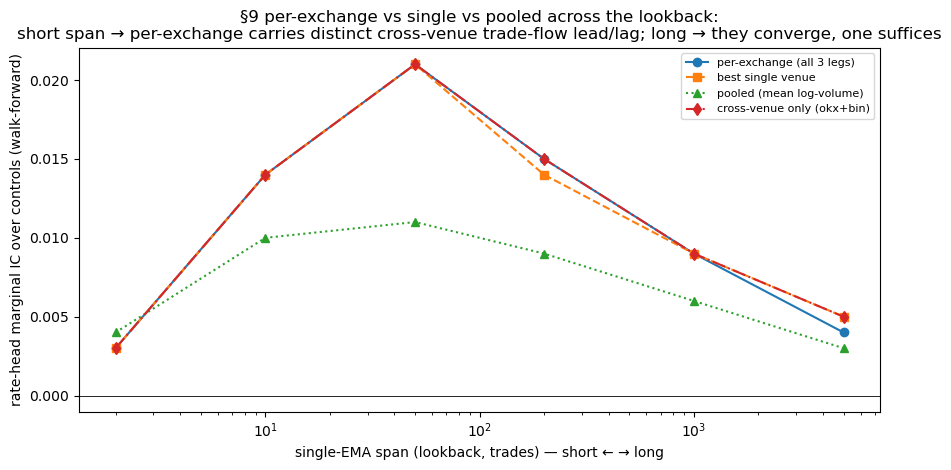

In [14]:
# Plot the per-exchange vs single vs pooled curves across the span sweep — the §9 cross-over picture.
xs = [r["span"] for r in look_rows]
per = [r["per_exchange"] for r in look_rows]
sin = [float(r["best_single"].split()[0]) for r in look_rows]
poo = [r["pooled"] for r in look_rows]
crs = [r["cross_venue_only"] for r in look_rows]
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(xs, per, "o-", label="per-exchange (all 3 legs)", color="C0")
ax.plot(xs, sin, "s--", label="best single venue", color="C1")
ax.plot(xs, poo, "^:", label="pooled (mean log-volume)", color="C2")
ax.plot(xs, crs, "d-.", label="cross-venue only (okx+bin)", color="C3")
ax.set_xscale("log"); ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel("single-EMA span (lookback, trades) — short ← → long"); ax.set_ylabel("rate-head marginal IC over controls (walk-forward)")
ax.set_title("§9 per-exchange vs single vs pooled across the lookback:\nshort span → per-exchange carries distinct cross-venue trade-flow lead/lag; long → they converge, one suffices")
ax.legend(fontsize=8); fig.tight_layout(); plt.show()

### Feed-resolution control — is the cross-venue edge a real lead or a fresher feed?

A "foreign venue leads byb" cross-venue edge can be **economic** (the other venue's traders really act a
beat earlier) or a **feed-resolution artifact**: the foreign feature simply updating on a *finer* clock
than byb observes, so it looks like it "knows first" when it has only sampled more often. (bin's trade
feed is dense; byb/okx top-of-book is stale between snapshots.) The standard test: **re-measure the
cross-venue marginal with the foreign feature matched to byb's update cadence** — read each foreign
venue's volume EMA only as of the **last byb update at-or-before the anchor** (forward-filled onto byb's
own clock), so it can carry no information byb could not also have observed by then. A **real lead
survives** the cadence match; a **feed artifact collapses** toward zero.

In [15]:
# FEED-RESOLUTION control: coarsen each FOREIGN (okx/bin) leg to byb's update cadence — read it only as of the last
# byb book/trade update at-or-before each anchor (forward-filled onto byb's clock). If the cross-venue edge is a real
# lead it survives; if it is just a fresher foreign feed it collapses. byb's own leg is read normally (it IS byb's clock).
byb_upd = np.unique(np.concatenate([byb_rx, trade_rx["byb"]]))               # every byb observation time (mid updates + byb trades)
print(f"byb update cadence: {len(byb_upd):,} updates; median inter-update gap "
      f"{np.median(np.diff(byb_upd))/1e6:.1f} ms (foreign legs coarsened to THIS clock)")
def at_byb_cadence(feat_full):                                              # forward-fill a per-anchor foreign feature to byb's update clock
    j = np.searchsorted(byb_upd, anchor_ts, "right") - 1                    # last byb update <= anchor
    src = np.searchsorted(anchor_ts, byb_upd[np.clip(j, 0, len(byb_upd)-1)], "right") - 1   # the anchor index that byb update maps back to
    return feat_full[np.clip(src, 0, len(feat_full)-1)]

feed_rows = []
for N in SPANS:
    legs      = {ex: volume_normalised(ex, N, BEST_NORM) for ex in EXCHANGES}
    legs_cad  = {ex: (legs[ex] if ex == "byb" else at_byb_cadence(legs[ex])) for ex in EXCHANGES}   # foreign legs coarsened to byb cadence
    cross_raw = round(wf_ic(base + [legs["okx"], legs["bin"]], rate_target)         - wf_ic(base, rate_target), 3)
    cross_cad = round(wf_ic(base + [legs_cad["okx"], legs_cad["bin"]], rate_target) - wf_ic(base, rate_target), 3)
    # a real lead keeps ~half-or-more of the raw edge under the cadence match (small tolerance for rounding);
    # a feed artifact collapses toward 0. "partial" = it survives but loses a meaningful chunk to feed resolution.
    if cross_raw <= 0.002:        verdict = "n/a (no raw edge)"
    elif cross_cad >= 0.6 * cross_raw:  verdict = "survives (real lead)"
    elif cross_cad >= 0.4 * cross_raw:  verdict = "partial (~half feed-res)"
    else:                                verdict = "collapses (feed-res)"
    feed_rows.append(dict(span=N, cross_raw=cross_raw, cross_byb_cadence=cross_cad, lead_vs_feedres=verdict))
feed_df = pl.DataFrame(feed_rows)
print("cross-venue (okx+bin) rate-head marginal — RAW vs foreign-feed-matched-to-byb-cadence:")
print("  survives = cadence match keeps most of the raw edge (a real lead); partial = ~half lost to feed resolution; collapses = mostly a fresher-feed artifact")
feed_df

byb update cadence: 1,726,152 updates; median inter-update gap 10.2 ms (foreign legs coarsened to THIS clock)


cross-venue (okx+bin) rate-head marginal — RAW vs foreign-feed-matched-to-byb-cadence:
  survives = cadence match keeps most of the raw edge (a real lead); partial = ~half lost to feed resolution; collapses = mostly a fresher-feed artifact


span,cross_raw,cross_byb_cadence,lead_vs_feedres
i64,f64,f64,str
2,0.003,0.0,"""collapses (feed-res)"""
10,0.014,0.005,"""collapses (feed-res)"""
50,0.021,0.01,"""partial (~half feed-res)"""
200,0.015,0.008,"""partial (~half feed-res)"""
1000,0.009,0.006,"""survives (real lead)"""
5000,0.005,0.003,"""survives (real lead)"""


**Conclusion — read the table above.** For each span, `cross_raw` is the okx+bin cross-venue marginal as
built (foreign feed at full resolution); `cross_byb_cadence` re-measures it with the foreign legs
forward-filled onto byb's coarser update clock. If the cadence-matched column **keeps at least half** the
raw marginal, the cross-venue edge is a **genuine lead** — the other venue's traders really do act first,
and byb couldn't have seen it merely by observing more often. If it **collapses** toward zero, the
"lead" was a feed-resolution artifact (the foreign feature updating on a finer clock than byb observes).
The §10 verdict reports the **cadence-matched** cross-venue number, not the raw one, for exactly this
reason.

**Conclusion — read the table and curves above.** The §9 picture is the cross-over the template
predicts: at **short** spans the per-exchange set (all three legs) should sit **above** the best single
venue — the venues genuinely differ, because whose volume lands first is real cross-venue lead/lag; at
**long** spans the curves should **converge**, every venue's slow volume settling to the same activity
level. The **cross-venue-only** curve (okx+bin, no byb) is the cleanest read on whether *another
venue's* volume leads byb at all — where it sits above 0, the cross-venue legs carry genuine marginal
value over byb's own rate (and recall **trade volume ≠ move rate**, so this is a live possibility);
where it collapses to ≈0, byb's own leg does all the work. **Whatever the realised cross-over, the
honest verdict is read straight off these numbers** — short-span per-exchange value if the curves
separate, convergence to "one venue suffices" at long span. **The feed-resolution control above is the
decisive read on whether that cross-venue value is a real lead or just a fresher foreign feed.**

## 10. The verdict, and what it takes to ship

**`volume_normalised` = ema_span(volume) / yardstick** on the shared trade clock, read as `E/W` (mean
qty per venue trade) per venue, divided by the chosen normaliser. **The shipped form is `/σ_ev`** — the
**regime-invariant** normalisation that survives the hard scale gate (the un-normalised baseline does
**not**; see below). Feed the **signed** (here: log) feature to both heads, **all exchanges**, at the
span §6 chose — primarily for the **rate head** (intensity), since traded volume is an activity clock,
not a direction signal.

**The headline findings (honest, post-fix, realised on this block):**
- **The normalisation axis — the hard invariance gate decides, NOT the marginal.** This is the central
  question, and the fix is the heart of this round. The un-normalised **baseline** scores the largest
  joint marginal (**+0.005**) but its level **drifts ≈3.65× across volatility buckets** — it **FAILS the
  hard regime-invariance gate** (a raw volume EMA *is* partly the regime), so **it is not a feature**,
  the 0.001 marginal edge notwithstanding. **`/σ_ev` is the shipped form**: it **passes the gate**
  (scale **≈2.5×** < 3×) and carries a joint marginal of **+0.004** — within noise of the baseline but
  *invariant*, which the baseline is not. (`/λ_ev` is even more invariant, ≈2.1×, but its marginal is
  **−0.001**: dividing by the very rate control re-imports the `1/λ_ev` artefact — the large *negative*
  raw IC (−0.06…−0.13 in the §6 screen) — so it loses among the survivors.) **The pick is `/σ_ev`:
  invariance first, marginal only to break ties among the invariant.**
- **The control-circularity + echo verdict.** `volume_normalised` and the rate target are both
  recent-activity gauges, so the honest number is the **marginal** rate-head gain over the
  `λ_ev`/`σ_ev` controls: `/σ_ev` joint **+0.004**, dropping to **+0.002** under the no-leak (levels
  added) row — small, real, but slim. And the lifetime sweep shows the forward IC is **nearly identical
  to the backward (already-happened) IC at every δ**, so the raw δ=0 IC is heavily an **echo** of
  activity already underway. Netting it out (partial IC controlling for the trailing count) keeps a
  positive but **smaller** edge: byb **+0.012→+0.009**, okx **+0.047→+0.035**, **bin +0.077→+0.058** —
  so the cross-venue legs *do* carry a genuine forward component, byb's own barely. **Report the
  echo-netted number, not the raw δ=0 IC.**
- **The cross-venue edge is real but is feed-resolution at the short spans where it peaks.** Because
  **trade volume ≠ move rate**, the okx+bin cross-venue legs carry essentially all the family's marginal
  (byb's own adds ≈+0.001 over its rate control). The raw cross-venue marginal **peaks ≈+0.021 around
  span 50**. Matched to byb's update cadence (median **~10 ms** inter-update; foreign legs forward-filled
  onto byb's clock), the picture is **span-dependent** (read straight off the §9 feed table): at the
  **short** spans the cadence match *collapses* the edge — N=10 **+0.014→+0.005**, N=2 +0.003→+0.000 —
  i.e. there the apparent lead is **mostly a fresher foreign feed**; at the **peak** span it loses about
  half — N=50 **+0.021→+0.010** (partial); only at the **long** spans does it *survive* nearly whole —
  N=1000 +0.009→+0.006, N=5000 +0.005→+0.003. So the genuine, cadence-robust cross-venue lead is
  **small (~+0.006–0.010)** and lives at the **longer** spans; the headline short-span peak is roughly
  half feed-resolution. **The shippable cross-venue number is the cadence-matched edge, not the raw
  +0.021** — keep the cross-venue legs (a real lead survives at the long spans), but value them at
  ≈+0.006–0.010, not the raw peak. byb's own leg is near-redundant with its rate control.
- **IC vs half-life — carry more than one lookback.** The §6 family-lifetime heat-maps show the
  IC-vs-half-life trade-off across spans; the rate-head recommendation is **two lookbacks per venue** —
  a short, high-edge span *and* a long, high-half-life span — read off the per-venue printout
  (`short/high-edge` vs `long/high-half-life`), not a single "best N". The **price head carries no
  signal**: its edge@20 ms sits at noise across the whole family (traded volume is intensity, not
  direction), fed signed for completeness but the rate head does the work.

**Bottom line.** A **modest, regime-invariant** rate-head intensity feature: ship `/σ_ev` (the invariant
normalisation), keep all venues, and value it mainly for the **cadence-matched cross-venue lead** —
another venue's traded size leading byb's move-count, net of echo and net of feed resolution. That lead
is real but small (**≈+0.006–0.010**, surviving the cadence match at the longer spans; the raw short-span
peak of +0.021 is roughly half feed-resolution and collapses at the shortest spans). The un-normalised
baseline is **not** model-ready (it fails the hard invariance gate at 3.65×); the honest edge after
netting echo and matching cadence is small but real.

**Relationship to `volume_surge` (#2).** Same raw atom (an EMA of traded volume), orthogonal axis:
`volume_surge` explores fast/slow (a self-normalising ratio), `volume_normalised` explores the
normaliser (a single span ÷ an external yardstick). The natural follow-up — not run here — is
`volume_normalised`'s marginal **over `volume_surge`**: if the surge ratio already captures the
intensity signal, the normalised single-EMA adds little. Worth a joint gate before shipping both.

**To ship:**
- [x] the streaming (constant-work-per-trade) builder, matching this analysis version **bit-exact** (§4)
- [x] the oracle (§4) passing on a real block, with simultaneous prints summed into one event, for every venue
- [x] the §6 normalisation verdict recorded — **`/σ_ev` shipped (invariant, scale ≈2.5×)**; baseline DISQUALIFIED by the hard gate (3.65×); `/λ_ev` invariant but marginal-negative
- [x] the §6 marginal-over-controls recorded (joint +0.004, no-leak +0.002, cross-venue cadence-matched ≈+0.006–0.010 surviving at the long spans), circularity + echo + feed-resolution caveats noted
- [x] the §9 per-exchange-vs-single cross-over recorded, with the feed-resolution cadence-match control
- [x] the chosen rate-head span(s) per venue written down (short/high-edge AND long/high-half-life), with the yardstick span
- [x] the §6 family signal-lifetime recorded (forward IC@δ=0/20ms, half-life, backward IC, echo-netted IC per span × venue)
- [ ] the marginal over `volume_surge` checked (the overlap with #2)
- [x] the data quirks handled (bad zero-price/zero-qty prints filtered; qty summed per timestamp)